# FIT5202 2026 S2 Assignment 1 : Analysing Parking & Congestion Patterns in Melbourne

## Table of Contents
* [Part 1 : Data Loading and Transformation](#part-1)  
    - [1.1 Data Preparation and Loading](#1.1)  
    - [1.2 Data Cleansing](#1.2)
    - [1.3 Partitition and Spark UI Evidence](#1.3)    
* [Part 2 : Working with DataFrames](#2-dataframes)  
    - [2.1-2.5 Query/Analysis](#2-dataframes)  
    - [2.6 Exploratory Analysis](#2.6)  
* [Part 3 : Query Optimisation](#part-3)  

## Generative AI Acknowledgement

I used ChatGPT as a support tool while completing this assignment. It was used to explain PySpark and Spark concepts, suggest and review code structures, assist with debugging and query optimisation, and improve the wording of discussions. I critically reviewed and adapted all suggestions, executed and validated the code, checked the outputs against the assignment requirements, and take full responsibility for the submitted work.

Note: Feel free to add Code/Markdown cells as you need.

# Part 1 : Data Loading and Transformation (10%) <a class="anchor" name="part-1"></a>
In this section, you need to create data frames from the given datasets, perform partitioning and use various operations to answer the queries.  

## 1.1 Data Preparation and Loading <a class="anchor" name="1.1"></a>
1. Configure the Spark session to run locally using four cores;
1. Assign an appropriate application name to the Spark session;
1. Set the session timezone explicitly to 'Australia/Melbourne';
1. Define and apply an explicit StructType schema when loading each CSV and JSON dataset. 
1. Print the schema and row count for each DataFrame;
1. Display the first five rows of each DataFrame to verify successful data loading.



In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    ArrayType,
    BooleanType,
    IntegerType,
    StringType,
    StructField,
    StructType
)

student_auth_code = "kzha0139"

spark = (
    SparkSession.builder
    # 1. Configure the Spark session to run locally using four cores;
    .master("local[4]")
    # 2. Assign an appropriate application name to the Spark session;
    .appName(f"FIT5202-A1-{student_auth_code}")
    # 3. Set the session timezone explicitly to 'Australia/Melbourne';
    .config("spark.sql.session.timeZone", "Australia/Melbourne")
    .getOrCreate()
)

sc = spark.sparkContext
sc.setLogLevel("WARN")

print("Spark version:", spark.version)
print("Spark master:", sc.master)
print("Application name:", sc.appName)
print(
    "Session timezone:",
    spark.conf.get("spark.sql.session.timeZone")
)

Spark version: 4.1.1
Spark master: local[4]
Application name: FIT5202-A1-kzha0139
Session timezone: Australia/Melbourne


In [2]:
import os
# 4.1 set the file path of csv and json file
DATA_DIR = (
    "fit5202_2026_s2_dataset_v2/"
    "fit5202_2026_s2_dataset_v2"
)

PARKING_PATH = f"{DATA_DIR}/sensordata.csv"
TRAFFIC_PATH = f"{DATA_DIR}/traffic_count.csv"
AREA_PATH = f"{DATA_DIR}/area.json"
STREET_PATH = f"{DATA_DIR}/street.json"

data_paths = {
    "Parking": PARKING_PATH,
    "Traffic": TRAFFIC_PATH,
    "Area": AREA_PATH,
    "Street": STREET_PATH
}

print("Notebook working directory:", os.getcwd())

for name, path in data_paths.items():
    print(f"{name}: exists={os.path.exists(path)}, path={path}")

Notebook working directory: /home/student
Parking: exists=True, path=fit5202_2026_s2_dataset_v2/fit5202_2026_s2_dataset_v2/sensordata.csv
Traffic: exists=True, path=fit5202_2026_s2_dataset_v2/fit5202_2026_s2_dataset_v2/traffic_count.csv
Area: exists=True, path=fit5202_2026_s2_dataset_v2/fit5202_2026_s2_dataset_v2/area.json
Street: exists=True, path=fit5202_2026_s2_dataset_v2/fit5202_2026_s2_dataset_v2/street.json


In [3]:
# 4.2 define schema for sensordata.csv
parking_schema = StructType([
    StructField("deviceid", StringType(), True),
    StructField("arrivaltime", StringType(), True),
    StructField("departuretime", StringType(), True),
    StructField("streetmarker", StringType(), True),
    StructField("signplateid", StringType(), True),
    StructField("sign", StringType(), True),
    StructField("streetid", IntegerType(), True),
    StructField("betweenstreet1id", IntegerType(), True),
    StructField("betweenstreet2id", IntegerType(), True),
    StructField("sideofstreet", IntegerType(), True),
    StructField("sidename", StringType(), True),
    StructField("bayid", IntegerType(), True),
    StructField("inviolation", BooleanType(), True),
    StructField("vehiclepresent", BooleanType(), True),
    StructField("areaid", IntegerType(), True)
])

In [4]:
# 4.3 define schema for traffic_count.csv
traffic_schema = StructType([
    StructField("d_year", IntegerType(), True),
    StructField("d_month", IntegerType(), True),
    StructField("d_day", IntegerType(), True),
    StructField("d_hour", IntegerType(), True),
    StructField("d_minute", IntegerType(), True),
    StructField("areaid", IntegerType(), True),
    StructField("traffic_count", IntegerType(), True)
])

In [5]:
# 4.4 define nested schema(areaid, areaname in area) for area.json
area_record_schema = StructType([
    StructField("areaid", IntegerType(), True),
    StructField("areaname", StringType(), True)
])

area_file_schema = StructType([
    StructField(
        "area",
        ArrayType(area_record_schema),
        True
    )
])

In [6]:
# 4.5 define nested schema(streetid, streetname in street) for street.json
street_record_schema = StructType([
    StructField("streetid", IntegerType(), True),
    StructField("streetname", StringType(), True)
])

street_file_schema = StructType([
    StructField(
        "street",
        ArrayType(street_record_schema),
        True
    )
])

In [7]:
# 4.6 apply schema to 2 csv file
parking_raw_df = (
    spark.read
    .option("header", True)
    .schema(parking_schema)
    .csv(PARKING_PATH)
)

traffic_raw_df = (
    spark.read
    .option("header", True)
    .schema(traffic_schema)
    .csv(TRAFFIC_PATH)
)

In [8]:
# 4.7 apply schma to 2 json file
area_nested_df = (
    spark.read
    .option("multiLine", True)
    .schema(area_file_schema)
    .json(AREA_PATH)
)

area_raw_df = (
    area_nested_df
    .select(F.explode("area").alias("area_record"))
    .select("area_record.*")
)

street_nested_df = (
    spark.read
    .option("multiLine", True)
    .schema(street_file_schema)
    .json(STREET_PATH)
)

street_raw_df = (
    street_nested_df
    .select(F.explode("street").alias("street_record"))
    .select("street_record.*")
)

In [9]:
dataframes = {
    "Parking DataFrame": parking_raw_df,
    "Traffic DataFrame": traffic_raw_df,
    "Area DataFrame": area_raw_df,
    "Street DataFrame": street_raw_df
}

for name, dataframe in dataframes.items():
    print(name)
    
    # 5. Print the schema for each DataFrame;
    dataframe.printSchema()
    # 6. Display the first five rows of each DataFrame to verify successful data loading.
    dataframe.show(5, truncate=False)

Parking DataFrame
root
 |-- deviceid: string (nullable = true)
 |-- arrivaltime: string (nullable = true)
 |-- departuretime: string (nullable = true)
 |-- streetmarker: string (nullable = true)
 |-- signplateid: string (nullable = true)
 |-- sign: string (nullable = true)
 |-- streetid: integer (nullable = true)
 |-- betweenstreet1id: integer (nullable = true)
 |-- betweenstreet2id: integer (nullable = true)
 |-- sideofstreet: integer (nullable = true)
 |-- sidename: string (nullable = true)
 |-- bayid: integer (nullable = true)
 |-- inviolation: boolean (nullable = true)
 |-- vehiclepresent: boolean (nullable = true)
 |-- areaid: integer (nullable = true)

+--------+----------------------+----------------------+------------+-----------+----+--------+----------------+----------------+------------+--------+-----+-----------+--------------+------+
|deviceid|arrivaltime           |departuretime         |streetmarker|signplateid|sign|streetid|betweenstreet1id|betweenstreet2id|sideofstreet

In [10]:
# 5. Print the row count for each DataFrame;
row_counts = {}

for name, dataframe in dataframes.items():
    row_count = dataframe.count()
    row_counts[name] = row_count

    print(f"{name}: {row_count:,} rows")

Parking DataFrame: 72,912,582 rows
Traffic DataFrame: 10,956,114 rows
Area DataFrame: 38 rows
Street DataFrame: 126 rows


### 1.2 Data Cleansing and Validation <a class="anchor" name="1.2"></a>
The following tasks must be completed to ensure data quality and consistency (feel free to add code block as you see fit):
1) Identify the missing-value representations within the dataset and convert them to null. Briefly state which values were treated as missing.


In [11]:
from pyspark.sql.types import StringType

# Common text values that may represent missing information
candidate_missing_tokens = [
    "na",
    "n/a",
    "null",
    "none",
    "unknown",
    "-",
    "?"
]


def profile_missing_values(dataframe, dataframe_name):
    # Get all string columns
    string_columns = [
        field.name
        for field in dataframe.schema.fields
        if isinstance(field.dataType, StringType)
    ]

    # Count existing Spark null values
    missing_count_expressions = [
        F.count(
            F.when(F.col(column_name).isNull(), 1)
        ).alias(f"{column_name}__null")
        for column_name in dataframe.columns
    ]

    # Count blank strings and text-based missing values
    for column_name in string_columns:
        normalised_value = F.lower(
            F.trim(F.col(column_name))
        )

        missing_count_expressions.extend([
            F.count(
                F.when(normalised_value == "", 1)
            ).alias(f"{column_name}__blank"),

            F.count(
                F.when(
                    normalised_value.isin(
                        candidate_missing_tokens
                    ),
                    1
                )
            ).alias(f"{column_name}__token")
        ])

    # Calculate all missing-value counts
    result = (
        dataframe
        .select(missing_count_expressions)
        .first()
        .asDict()
    )
    print(dataframe_name)


    non_zero_result_found = False

    # Display only non-zero counts
    for metric_name, metric_count in result.items():
        if metric_count and metric_count > 0:
            print(f"{metric_name}: {metric_count:,}")
            non_zero_result_found = True

    if not non_zero_result_found:
        print("No missing values found.")

In [12]:
# Profile missing values in every DataFrame
for dataframe_name, dataframe in dataframes.items():
    profile_missing_values(
        dataframe,
        dataframe_name
    )

Parking DataFrame
signplateid__null: 25,195,820
sign__null: 25,195,820
betweenstreet2id__null: 10,606,993
Traffic DataFrame
No missing values found.
Area DataFrame
areaname__blank: 1
Street DataFrame
No missing values found.


In [13]:
# Display the blank AreaName record
area_raw_df.filter(
    F.trim(F.col("areaname")) == ""
).show(truncate=False)

+------+--------+
|areaid|areaname|
+------+--------+
|7     |        |
+------+--------+



In [14]:
def convert_missing_values_to_null(dataframe):
    # Start with the original DataFrame
    cleaned_dataframe = dataframe

    # Process string columns only
    string_columns = [
        field.name
        for field in dataframe.schema.fields
        if isinstance(field.dataType, StringType)
    ]

    for column_name in string_columns:
        normalised_value = F.lower(
            F.trim(F.col(column_name))
        )

        # Match blank strings or missing-value tokens
        is_missing = (
            (normalised_value == "")
            | normalised_value.isin(
                candidate_missing_tokens
            )
        )

        # Convert matched values to Spark null
        cleaned_dataframe = (
            cleaned_dataframe
            .withColumn(
                column_name,
                F.when(
                    is_missing,
                    F.lit(None).cast(StringType())
                ).otherwise(F.col(column_name))
            )
        )

    return cleaned_dataframe

In [15]:
# Create cleaned DataFrames
parking_clean_df = convert_missing_values_to_null(
    parking_raw_df
)

traffic_clean_df = convert_missing_values_to_null(
    traffic_raw_df
)

area_clean_df = convert_missing_values_to_null(
    area_raw_df
)

street_clean_df = convert_missing_values_to_null(
    street_raw_df
)

In [16]:
# Compare values before and after cleaning
print(
    "Raw blank AreaName count:",
    area_raw_df.filter(
        F.trim(F.col("areaname")) == ""
    ).count()
)

print(
    "Clean null AreaName count:",
    area_clean_df.filter(
        F.col("areaname").isNull()
    ).count()
)

# Display the converted record
area_clean_df.filter(
    F.col("areaname").isNull()
).show(truncate=False)

Raw blank AreaName count: 1
Clean null AreaName count: 1
+------+--------+
|areaid|areaname|
+------+--------+
|7     |NULL    |
+------+--------+



The missing-value profile identified empty CSV fields and one blank string as
the missing-value representations in the supplied datasets. Empty CSV fields
in `signplateid`, `sign` and `betweenstreet2id` were already interpreted as
Spark null values during loading. One blank `areaname` value was identified
and converted to null.

No occurrences of `NA`, `N/A`, `null`, `none`, `unknown`, `-` or `?` were
found. Existing null values were retained, while empty and whitespace-only
strings were converted to Spark null values. The original DataFrames were
kept unchanged, and separate cleaned DataFrames were created for subsequent
tasks.

2) Parse the 'ArrivalTime' and 'DepartureTime' columns and convert them to timestamp format. 

In [17]:
# Define the source timestamp format
timestamp_pattern = "MM/dd/yyyy hh:mm:ss a"

parking_clean_df = (
    parking_clean_df

    # Keep the original strings for validation
    .withColumn(
        "arrival_time_raw",
        F.col("arrivaltime")
    )
    .withColumn(
        "departure_time_raw",
        F.col("departuretime")
    )

    # Parse ArrivalTime as timestamp
    .withColumn(
        "arrivaltime",
        F.try_to_timestamp(
            F.col("arrivaltime"),
            F.lit(timestamp_pattern)
        )
    )

    # Parse DepartureTime as timestamp
    .withColumn(
        "departuretime",
        F.try_to_timestamp(
            F.col("departuretime"),
            F.lit(timestamp_pattern)
        )
    )
)

In [18]:
# Compare raw strings with parsed timestamps
parking_clean_df.select(
    "arrival_time_raw",
    "arrivaltime",
    "departure_time_raw",
    "departuretime"
).show(5, truncate=False)

+----------------------+-------------------+----------------------+-------------------+
|arrival_time_raw      |arrivaltime        |departure_time_raw    |departuretime      |
+----------------------+-------------------+----------------------+-------------------+
|10/23/2018 06:49:29 AM|2018-10-23 06:49:29|10/23/2018 06:54:24 AM|2018-10-23 06:54:24|
|02/07/2018 07:30:00 PM|2018-02-07 19:30:00|02/07/2018 07:56:23 PM|2018-02-07 19:56:23|
|11/22/2018 07:22:38 AM|2018-11-22 07:22:38|11/22/2018 07:28:22 AM|2018-11-22 07:28:22|
|09/18/2018 09:24:56 PM|2018-09-18 21:24:56|09/18/2018 09:27:44 PM|2018-09-18 21:27:44|
|01/04/2018 12:00:00 AM|2018-01-04 00:00:00|01/04/2018 03:45:46 AM|2018-01-04 03:45:46|
+----------------------+-------------------+----------------------+-------------------+
only showing top 5 rows


In [19]:
# Confirm the converted column types
parking_clean_df.select(
    "arrival_time_raw",
    "arrivaltime",
    "departure_time_raw",
    "departuretime"
).printSchema()

root
 |-- arrival_time_raw: string (nullable = true)
 |-- arrivaltime: timestamp (nullable = true)
 |-- departure_time_raw: string (nullable = true)
 |-- departuretime: timestamp (nullable = true)



The `ArrivalTime` and `DepartureTime` columns were parsed using the
`MM/dd/yyyy hh:mm:ss a` format and converted from strings to Spark timestamp
values. The original string values were retained in separate columns to
support the identification of parsing failures during validation.

3) Convert the “DeviceId” to an appropriate numeric type. 

In [20]:
# Check the numeric range of DeviceId
parking_clean_df.agg(
    F.min("deviceid").alias("MinDeviceId"),
    F.max("deviceid").alias("MaxDeviceId")
).show()

+-----------+-----------+
|MinDeviceId|MaxDeviceId|
+-----------+-----------+
|      10036|      28532|
+-----------+-----------+



In [21]:
parking_clean_df = (
    parking_clean_df

    # Keep the original value for validation
    .withColumn(
        "device_id_raw",
        F.col("deviceid")
    )

    # Convert DeviceId to IntegerType safely
    .withColumn(
        "deviceid",
        F.col("deviceid").try_cast("int")
    )
)

In [22]:
# Compare the original and converted values
parking_clean_df.select(
    "device_id_raw",
    "deviceid"
).show(5, truncate=False)

+-------------+--------+
|device_id_raw|deviceid|
+-------------+--------+
|17193        |17193   |
|17193        |17193   |
|17195        |17195   |
|17195        |17195   |
|17195        |17195   |
+-------------+--------+
only showing top 5 rows


In [23]:
# Compare the original and converted data type
parking_clean_df.select(
    "device_id_raw",
    "deviceid"
).printSchema()

root
 |-- device_id_raw: string (nullable = true)
 |-- deviceid: integer (nullable = true)



The `DeviceId` column was converted from string to `IntegerType`. The original string value was retained in `device_id_raw` so that non-null source values that failed numeric conversion could be identified during validation.

4) Calculate a new “DurationMinutes” column using the arrival and departure timestamp. Store the result as a DoubleType value and rounded to two decimal places.

In [24]:
parking_clean_df = parking_clean_df.withColumn(
    "DurationMinutes",

    # Calculate the duration in minutes
    F.round(
        (
            F.col("departuretime").cast("long")
            - F.col("arrivaltime").cast("long")
        ) / 60.0,
        2
    ).cast("double")
)

In [25]:
# Display calculated parking durations
parking_clean_df.select(
    "arrivaltime",
    "departuretime",
    "DurationMinutes"
).show(10, truncate=False)

+-------------------+-------------------+---------------+
|arrivaltime        |departuretime      |DurationMinutes|
+-------------------+-------------------+---------------+
|2018-10-23 06:49:29|2018-10-23 06:54:24|4.92           |
|2018-02-07 19:30:00|2018-02-07 19:56:23|26.38          |
|2018-11-22 07:22:38|2018-11-22 07:28:22|5.73           |
|2018-09-18 21:24:56|2018-09-18 21:27:44|2.8            |
|2018-01-04 00:00:00|2018-01-04 03:45:46|225.77         |
|2018-07-13 00:00:00|2018-07-13 06:06:43|366.72         |
|2018-01-29 19:07:39|2018-01-29 19:11:53|4.23           |
|2018-10-20 06:29:15|2018-10-20 07:15:02|45.78          |
|2018-08-06 18:42:28|2018-08-06 18:49:11|6.72           |
|2018-01-03 07:02:17|2018-01-03 07:05:08|2.85           |
+-------------------+-------------------+---------------+
only showing top 10 rows


In [26]:
parking_clean_df.select(
    "DurationMinutes"
).printSchema()

root
 |-- DurationMinutes: double (nullable = true)



`DurationMinutes` was calculated by converting the arrival and departure
timestamps to Unix seconds, subtracting the arrival value from the departure
value, and dividing the result by 60. The result was rounded to two decimal
places and stored as DoubleType.

Records with missing or unparseable timestamps produce a null duration.
Negative duration values were retained at this stage for investigation in the
next validation task.

5) Identify and report records where the departure time is earlier than the arrival time. Briefly discuss any pattern observed and state how these records will be handled in duration-based queries.

In [27]:
from pyspark import StorageLevel

# Keep records where departure is earlier than arrival, negative parking durations
negative_duration_df = (
    parking_clean_df
    .filter(
        F.col("DurationMinutes") < 0
    )
    .cache()
)

In [28]:
# Summarise negative duration records
negative_duration_summary_df = negative_duration_df.agg(
    F.count("*").alias(
        "NegativeDurationRecords"
    ),

    F.round(
        F.min("DurationMinutes"),
        2
    ).alias(
        "MostNegativeDurationMinutes"
    ),

    F.round(
        F.max("DurationMinutes"),
        2
    ).alias(
        "ClosestToZeroDurationMinutes"
    ),

    F.round(
        F.avg("DurationMinutes"),
        2
    ).alias(
        "AverageNegativeDurationMinutes"
    )
)

negative_duration_summary_df.show(
    truncate=False
)

+-----------------------+---------------------------+----------------------------+------------------------------+
|NegativeDurationRecords|MostNegativeDurationMinutes|ClosestToZeroDurationMinutes|AverageNegativeDurationMinutes|
+-----------------------+---------------------------+----------------------------+------------------------------+
|408                    |-493288.88                 |-0.12                       |-74094.87                     |
+-----------------------+---------------------------+----------------------------+------------------------------+



A total of 408 records had negative durations, representing approximately 0.00056% of all parking records. The durations ranged from -493,288.88 to -0.12 minutes, indicating both minor timing inconsistencies and severe date-matching errors.

In [29]:
# Display the most severe negative durations
negative_duration_df.select(
    "deviceid",
    "bayid",
    "areaid",
    "arrival_time_raw",
    "departure_time_raw",
    "arrivaltime",
    "departuretime",
    "DurationMinutes"
).orderBy(
    F.asc("DurationMinutes")
).show(20, truncate=False)

+--------+-----+------+----------------------+----------------------+-------------------+-------------------+---------------+
|deviceid|bayid|areaid|arrival_time_raw      |departure_time_raw    |arrivaltime        |departuretime      |DurationMinutes|
+--------+-----+------+----------------------+----------------------+-------------------+-------------------+---------------+
|17595   |6519 |35    |12/26/2019 07:30:00 AM|01/17/2019 06:01:07 PM|2019-12-26 07:30:00|2019-01-17 18:01:07|-493288.88     |
|17595   |6519 |35    |12/22/2019 06:30:00 PM|01/18/2019 07:05:43 AM|2019-12-22 18:30:00|2019-01-18 07:05:43|-487404.28     |
|17595   |6519 |35    |12/22/2019 07:30:00 AM|01/18/2019 07:00:49 AM|2019-12-22 07:30:00|2019-01-18 07:00:49|-486749.18     |
|17595   |6519 |35    |12/24/2019 07:30:00 AM|01/20/2019 02:53:14 PM|2019-12-24 07:30:00|2019-01-20 14:53:14|-486276.77     |
|17595   |6519 |35    |12/20/2019 07:30:00 AM|01/19/2019 05:55:34 AM|2019-12-20 07:30:00|2019-01-19 05:55:34|-482494.4

The most severe records had departure timestamps several months earlier than their arrival timestamps. DeviceId 17595 and BayId 6519 appeared repeatedly, suggesting a possible sensor-event matching problem.

In [30]:
# Count records by negative-duration magnitude
negative_duration_pattern_df = negative_duration_df.agg(
    F.sum(
        F.when(
            F.col("DurationMinutes") >= -60,
            1
        ).otherwise(0)
    ).alias(
        "LessThanOneHourEarlier"
    ),

    F.sum(
        F.when(
            (F.col("DurationMinutes") < -60)
            & (F.col("DurationMinutes") >= -1440),
            1
        ).otherwise(0)
    ).alias(
        "OneHourToOneDayEarlier"
    ),

    F.sum(
        F.when(
            F.col("DurationMinutes") < -1440,
            1
        ).otherwise(0)
    ).alias(
        "MoreThanOneDayEarlier"
    )
)

negative_duration_pattern_df.show(
    truncate=False
)

+----------------------+----------------------+---------------------+
|LessThanOneHourEarlier|OneHourToOneDayEarlier|MoreThanOneDayEarlier|
+----------------------+----------------------+---------------------+
|112                   |148                   |148                  |
+----------------------+----------------------+---------------------+



Of the 408 invalid records, 112 were less than one hour earlier, 148 were between one hour and one day earlier, and 148 were more than one day earlier.

In [31]:
# Check whether invalid records cluster on specific dates
negative_duration_df.groupBy(
    F.to_date(
        F.col("arrivaltime")
    ).alias("ArrivalDate")
).count().orderBy(
    F.desc("count"),
    F.asc("ArrivalDate")
).show(20, truncate=False)

+-----------+-----+
|ArrivalDate|count|
+-----------+-----+
|2019-10-06 |51   |
|2018-03-19 |37   |
|2018-10-07 |26   |
|2018-12-04 |21   |
|2019-05-08 |13   |
|2018-07-06 |12   |
|2019-04-14 |8    |
|2019-07-26 |8    |
|2018-04-21 |7    |
|2019-06-08 |7    |
|2019-07-28 |7    |
|2018-06-29 |6    |
|2019-03-04 |6    |
|2018-06-26 |5    |
|2018-06-27 |5    |
|2018-07-03 |5    |
|2019-09-16 |5    |
|2019-05-02 |4    |
|2019-06-11 |4    |
|2019-10-19 |4    |
+-----------+-----+
only showing top 20 rows


Negative-duration records were concentrated on several arrival dates. The highest counts occurred on 2019-10-06 (51), 2018-03-19 (37) and 2018-10-07 (26). The two October dates coincide with Melbourne daylight-saving transitions, but clock changes alone cannot explain durations that are days or months negative. Together with the concentration among particular devices and bays, the results suggest that incorrect sensor-event matching is the more likely general cause.

In [32]:
# Check whether anomalies cluster by device and bay
negative_duration_df.groupBy(
    "deviceid",
    "bayid",
    "areaid"
).agg(
    F.count("*").alias(
        "NegativeDurationCount"
    ),

    F.round(
        F.min("DurationMinutes"),
        2
    ).alias(
        "MostNegativeDurationMinutes"
    ),

    F.round(
        F.max("DurationMinutes"),
        2
    ).alias(
        "ClosestToZeroDurationMinutes"
    )
).orderBy(
    F.desc("NegativeDurationCount")
).show(10, truncate=False)

+--------+-----+------+---------------------+---------------------------+----------------------------+
|deviceid|bayid|areaid|NegativeDurationCount|MostNegativeDurationMinutes|ClosestToZeroDurationMinutes|
+--------+-----+------+---------------------+---------------------------+----------------------------+
|17595   |6519 |35    |95                   |-493288.88                 |-44207.15                   |
|18199   |882  |11    |22                   |-124890.0                  |-53463.75                   |
|19904   |3205 |16    |6                    |-416090.1                  |-58630.55                   |
|20233   |3978 |16    |4                    |-329441.58                 |-257741.65                  |
|18689   |1708 |14    |3                    |-427022.7                  |-211740.0                   |
|19044   |2555 |25    |3                    |-561.23                    |-33.05                      |
|18468   |632  |33    |3                    |-421258.32                 |

DeviceId 17595 and BayId 6519 accounted for 95 negative-duration records, or approximately 23.28% of all invalid durations. The concentration among a small number of devices suggests systematic sensor or event-matching issues.

In [33]:
# Release the cached anomaly DataFrame
negative_duration_df.unpersist()

DataFrame[deviceid: int, arrivaltime: timestamp, departuretime: timestamp, streetmarker: string, signplateid: string, sign: string, streetid: int, betweenstreet1id: int, betweenstreet2id: int, sideofstreet: int, sidename: string, bayid: int, inviolation: boolean, vehiclepresent: boolean, areaid: int, arrival_time_raw: string, departure_time_raw: string, device_id_raw: string, DurationMinutes: double]

6) Explain how records with missing or invalid departure information will be handled in subsequent duration-based queries.

In [34]:
# Keep records with valid durations
valid_duration_df = parking_clean_df.filter(
    F.col("DurationMinutes").isNotNull()
    & (F.col("DurationMinutes") >= 0)
)

Records with missing or unparseable departure information produce a null DurationMinutes value, while records where DepartureTime is earlier than ArrivalTime produce a negative value. These records will be retained because their arrival, location and violation information may still be valid. Null and negative durations will only be excluded from metrics that require a valid parking duration, but the records may still be included in analyses that do not use duration.

7) Display and print the schema for DeviceId, ArrivalTime, DepartureTime and DurationMinutes.

In [35]:
# Select cleaned columns for validation
parking_validation_df = parking_clean_df.select(
    F.col("deviceid").alias("DeviceId"),
    F.col("arrivaltime").alias("ArrivalTime"),
    F.col("departuretime").alias("DepartureTime"),
    F.col("DurationMinutes")
)

parking_validation_df.show(5, truncate=False)
parking_validation_df.printSchema()

+--------+-------------------+-------------------+---------------+
|DeviceId|ArrivalTime        |DepartureTime      |DurationMinutes|
+--------+-------------------+-------------------+---------------+
|17193   |2018-10-23 06:49:29|2018-10-23 06:54:24|4.92           |
|17193   |2018-02-07 19:30:00|2018-02-07 19:56:23|26.38          |
|17195   |2018-11-22 07:22:38|2018-11-22 07:28:22|5.73           |
|17195   |2018-09-18 21:24:56|2018-09-18 21:27:44|2.8            |
|17195   |2018-01-04 00:00:00|2018-01-04 03:45:46|225.77         |
+--------+-------------------+-------------------+---------------+
only showing top 5 rows
root
 |-- DeviceId: integer (nullable = true)
 |-- ArrivalTime: timestamp (nullable = true)
 |-- DepartureTime: timestamp (nullable = true)
 |-- DurationMinutes: double (nullable = true)



8) Display a validation summary table containing the count for each of the following:
- total parking records;
- ArrivalTime parsing failures;
- DepartureTime parsing failures;
- DeviceId conversion failures;
- records with missing DepartureTime;
- records where DepartureTime is earlier than ArrivalTime.


In [36]:
# Create the validation summary
validation_summary_df = parking_clean_df.agg(
    
    # Count total parking records
    F.count("*").alias("TotalParkingRecords"),

    # Count ArrivalTime parsing failures
    F.sum(
        F.when(
            F.col("arrival_time_raw").isNotNull()
            & F.col("arrivaltime").isNull(),
            1
        ).otherwise(0)
    ).alias("ArrivalTimeParsingFailures"),

    # Count DepartureTime parsing failures
    F.sum(
        F.when(
            F.col("departure_time_raw").isNotNull()
            & F.col("departuretime").isNull(),
            1
        ).otherwise(0)
    ).alias("DepartureTimeParsingFailures"),

    # Count DeviceId conversion failures
    F.sum(
        F.when(
            F.col("device_id_raw").isNotNull()
            & F.col("deviceid").isNull(),
            1
        ).otherwise(0)
    ).alias("DeviceIdConversionFailures"),

    # Count records with missing DepartureTime
    F.sum(
        F.when(
            F.col("departure_time_raw").isNull(),
            1
        ).otherwise(0)
    ).alias("MissingDepartureTime"),

    # Count records where DepartureTime is earlier than ArrivalTime
    F.sum(
        F.when(
            F.col("DurationMinutes") < 0,
            1
        ).otherwise(0)
    ).alias("DepartureEarlierThanArrival")
)

# Display the validation summary
validation_summary_df.show(truncate=False)

+-------------------+--------------------------+----------------------------+--------------------------+--------------------+---------------------------+
|TotalParkingRecords|ArrivalTimeParsingFailures|DepartureTimeParsingFailures|DeviceIdConversionFailures|MissingDepartureTime|DepartureEarlierThanArrival|
+-------------------+--------------------------+----------------------------+--------------------------+--------------------+---------------------------+
|72912582           |0                         |0                           |0                         |0                   |408                        |
+-------------------+--------------------------+----------------------------+--------------------------+--------------------+---------------------------+



### 1.3 Partition and Spark UI Evidence <a class="anchor" name="1.3"></a>
1.3.1) Display the total number of partitions within the cleaned parking DataFrame.

In [37]:
# Display the total number of partitions
print(
    "Number of partitions:",
    parking_clean_df.rdd.getNumPartitions()
)

Number of partitions: 69


1.3.2) Print the number of records in each partition. Immediately before running this action, set the following Spark Job description: sc.setJobDescription(f"A1-P1-{student_auth_code}")

In [97]:
# Count records in each partition
partition_count_rdd = (
    parking_clean_df
    .select("deviceid")
    .rdd
    .mapPartitionsWithIndex(
        lambda partition_id, rows: [
            (partition_id, sum(1 for _ in rows))
        ]
    )
)

# Set the required job description
sc.setJobDescription(f"A1-P1-{student_auth_code}")

# Trigger the Spark action
partition_record_counts = partition_count_rdd.collect()

# Reset the job description
sc.setJobDescription(None)

# Print the record count for each partition
for partition_id, record_count in sorted(partition_record_counts):
    print(
        f"Partition {partition_id}: "
        f"{record_count:,} records"
    )

Partition 0: 1,093,088 records
Partition 1: 1,045,808 records
Partition 2: 1,043,416 records
Partition 3: 1,054,580 records
Partition 4: 1,095,648 records
Partition 5: 1,064,542 records
Partition 6: 1,073,063 records
Partition 7: 1,085,498 records
Partition 8: 1,069,231 records
Partition 9: 1,043,017 records
Partition 10: 1,049,272 records
Partition 11: 1,059,697 records
Partition 12: 1,051,963 records
Partition 13: 1,052,721 records
Partition 14: 1,047,821 records
Partition 15: 1,069,659 records
Partition 16: 1,051,222 records
Partition 17: 1,069,043 records
Partition 18: 1,072,379 records
Partition 19: 1,042,332 records
Partition 20: 1,053,826 records
Partition 21: 1,072,522 records
Partition 22: 1,053,381 records
Partition 23: 1,059,832 records
Partition 24: 1,058,740 records
Partition 25: 1,061,174 records
Partition 26: 1,056,094 records
Partition 27: 1,060,892 records
Partition 28: 1,059,880 records
Partition 29: 1,069,792 records
Partition 30: 1,068,101 records
Partition 31: 1,06

1.3.3) Include a set of screenshots from the Spark UI tab that clearly show:  
- the job tab with the specified job description;
- the relevant stage and its number of tasks
- the task input size, input records or task-duration distribution.

<img src="screenshots/part1/p1_jobs.png" width="100%">

**Figure 1:** Spark Jobs tab showing Job 44 with the required job description `A1-P1-kzha0139`.

<img src="screenshots/part1/p1_job_details.png" width="100%">

**Figure 2:** Job 44 details showing Stage 60 with 69 completed tasks and 8.6 GiB of input.

<img src="screenshots/part1/p1_stage_details.png" width="100%">

**Figure 3:** Stage 60 details showing the task timeline and the input-size, input-record and task-duration distributions.

1.3.4) Analyse the figures in the screenshot and briefly comment on whether the workload appears evenly distributed across the partitions. If not, why?

The workload appears broadly balanced. Stage 60 processed 72,912,582 records (8.6 GiB) across 69 tasks. The 25th percentile, median and 75th percentile input sizes were all 128.1 MiB, while task durations ranged only from 3 to 6 seconds. The smallest partition contained 69.1 MiB and 580,174 records, which was likely the final residual CSV split rather than evidence of significant data skew.

1.3.5) Provide a concise explanation detailing how Spark determines the initial number and approximate size of input partitions when reading from a CSV file.

When reading a splittable CSV file, Spark determines the initial partitions mainly from the input file size and `spark.sql.files.maxPartitionBytes`, which is approximately 128 MiB by default. Spark divides large files into splits close to this target size while preserving complete CSV records. Therefore, the 8.6 GiB parking file produced 69 partitions, with most partitions close to 128.1 MiB and a smaller final partition containing the remaining 69.1 MiB. The `local[4]` setting controls the number of tasks that can run concurrently, not the number of input partitions.

## Part 2. Working with DataFrames (35%) <a class="anchor" name="2-dataframes"></a>
In this section, you need to use DataFrame functions to answer the queries.

2.1 Create the time attributes  
2.1.1) From ArrivalTime, create columns for: year; month; day of week;  arrival hour and arrival minute;.

In [39]:
# Extract the year
parking_time_df = parking_clean_df.withColumn(
    "Year",
    F.year(F.col("arrivaltime"))
)

# Extract the month
parking_time_df = parking_time_df.withColumn(
    "Month",
    F.month(F.col("arrivaltime"))
)

# Extract the day of week
parking_time_df = parking_time_df.withColumn(
    "DayOfWeek",
    F.dayofweek(F.col("arrivaltime"))
)

# Extract the arrival hour
parking_time_df = parking_time_df.withColumn(
    "ArrivalHour",
    F.hour(F.col("arrivaltime"))
)

# Extract the arrival minute
parking_time_df = parking_time_df.withColumn(
    "ArrivalMinute",
    F.minute(F.col("arrivaltime"))
)

2.1.2) With day of week and hour and minutes, create a new column named isPeak and set the value to True or False (i.e. True = Peak Hour, False = Non-peak hour).  
- Peak hours are:
- Weekdays 7:00 - 9:00 am (excluding 9:00 am) and 4:00 - 6:30 pm ( excluding 6:30 pm).
- Non-peak hours are times outside these periods.
- Represent day of week using Spark’s convention: 1 = Sunday, 2 = Monday……

In [40]:
# Convert arrival time to minutes after midnight
arrival_minutes_of_day = (
    F.col("ArrivalHour") * 60
    + F.col("ArrivalMinute")
)

# Identify weekdays
is_weekday = F.col("DayOfWeek").between(2, 6)

# Define the morning peak period
is_morning_peak = (
    (arrival_minutes_of_day >= 7 * 60)
    & (arrival_minutes_of_day < 9 * 60)
)

# Define the evening peak period
is_evening_peak = (
    (arrival_minutes_of_day >= 16 * 60)
    & (arrival_minutes_of_day < 18 * 60 + 30)
)

# Create the peak-hour indicator
parking_time_df = parking_time_df.withColumn(
    "isPeak",
    F.when(
        is_weekday
        & (is_morning_peak | is_evening_peak),
        True
    ).otherwise(False)
)

2.1.3) Display five rows containing ArrivalTime, year, month, day of week, arrival hour, arrival minute and isPeak, and print the relevant schema.

In [41]:
# Select the time attributes for validation
time_attribute_validation_df = parking_time_df.select(
    F.col("arrivaltime").alias("ArrivalTime"),
    "Year",
    "Month",
    "DayOfWeek",
    "ArrivalHour",
    "ArrivalMinute",
    "isPeak"
)

# Display the first five rows
time_attribute_validation_df.show(5, truncate=False)

# Print the relevant schema
time_attribute_validation_df.printSchema()

+-------------------+----+-----+---------+-----------+-------------+------+
|ArrivalTime        |Year|Month|DayOfWeek|ArrivalHour|ArrivalMinute|isPeak|
+-------------------+----+-----+---------+-----------+-------------+------+
|2018-10-23 06:49:29|2018|10   |3        |6          |49           |false |
|2018-02-07 19:30:00|2018|2    |4        |19         |30           |false |
|2018-11-22 07:22:38|2018|11   |5        |7          |22           |true  |
|2018-09-18 21:24:56|2018|9    |3        |21         |24           |false |
|2018-01-04 00:00:00|2018|1    |5        |0          |0            |false |
+-------------------+----+-----+---------+-----------+-------------+------+
only showing top 5 rows
root
 |-- ArrivalTime: timestamp (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- DayOfWeek: integer (nullable = true)
 |-- ArrivalHour: integer (nullable = true)
 |-- ArrivalMinute: integer (nullable = true)
 |-- isPeak: boolean (nullable = f

2.2 Join the cleaned parking sensor data with both lookup tables to add the area and street names. (Note:The area and street lookup table is provided in JSON format).  
Select an appropriate join type;
- Report the number of parking records that do not match an area look up row and the number that do not match a street lookup row. 
- Identify a suitable join strategy for these joins and justify your choice.
- Display the first five joined records with the following columns: DeviceId, AreaId, AreaName, StreetId, and StreetName.

In [42]:
# Prepare the area lookup table
area_lookup_df = area_clean_df.select(
    F.col("areaid").alias("AreaLookupId"),
    F.col("areaname").alias("AreaName")
)

# Prepare the street lookup table
street_lookup_df = street_clean_df.select(
    F.col("streetid").alias("StreetLookupId"),
    F.col("streetname").alias("StreetName")
)

In [43]:
# Join the area lookup
parking_area_df = parking_time_df.alias("parking").join(
    F.broadcast(area_lookup_df).alias("area"),
    F.col("parking.areaid") == F.col("area.AreaLookupId"),
    "left"
).select(
    "parking.*",
    F.col("area.AreaLookupId"),
    F.col("area.AreaName")
)

In [44]:
# Join the street lookup
parking_enriched_df = parking_area_df.alias("parking_area").join(
    F.broadcast(street_lookup_df).alias("street"),
    F.col("parking_area.streetid")
    == F.col("street.StreetLookupId"),
    "left"
).select(
    "parking_area.*",
    F.col("street.StreetLookupId"),
    F.col("street.StreetName")
)

Left joins were used so that all parking records stayed in the result, even if a matching area or street could not be found. Unmatched records would have null lookup fields, making them easy to count. In this dataset, all parking records found matching area and street rows. Broadcast joins were used because the lookup tables are very small, with only 38 area rows and 126 street rows, compared with over 72 million parking records. Spark can send these small tables to each worker instead of moving the large parking dataset, which reduces data shuffling and improves performance.

In [45]:
# Report the join validation results
join_validation_summary_df = parking_enriched_df.agg(
    F.count("*").alias("TotalParkingRecordsAfterJoin"),

    # Count unmatched area records
    F.sum(
        F.when(
            F.col("AreaLookupId").isNull(),
            1
        ).otherwise(0)
    ).alias("UnmatchedAreaRecords"),

    # Count unmatched street records
    F.sum(
        F.when(
            F.col("StreetLookupId").isNull(),
            1
        ).otherwise(0)
    ).alias("UnmatchedStreetRecords")
)

join_validation_summary_df.show(truncate=False)

+----------------------------+--------------------+----------------------+
|TotalParkingRecordsAfterJoin|UnmatchedAreaRecords|UnmatchedStreetRecords|
+----------------------------+--------------------+----------------------+
|72912582                    |0                   |0                     |
+----------------------------+--------------------+----------------------+



In [46]:
# Display the first five joined records
parking_enriched_df.select(
    F.col("deviceid").alias("DeviceId"),
    F.col("areaid").alias("AreaId"),
    "AreaName",
    F.col("streetid").alias("StreetId"),
    "StreetName"
).show(5, truncate=False)

+--------+------+---------+--------+--------------+
|DeviceId|AreaId|AreaName |StreetId|StreetName    |
+--------+------+---------+--------+--------------+
|17193   |35    |Docklands|528     |COLLINS STREET|
|17193   |35    |Docklands|528     |COLLINS STREET|
|17195   |35    |Docklands|528     |COLLINS STREET|
|17195   |35    |Docklands|528     |COLLINS STREET|
|17195   |35    |Docklands|528     |COLLINS STREET|
+--------+------+---------+--------+--------------+
only showing top 5 rows


### 2.3 Compare Parking Activity and Violation Rates
The council would like to compare parking activity and violation patterns during peak and off-peak periods.  
For each parking area:
- PeakDailyAverage: the average number of valid peak-hour sessions per active weekday.
- PeakViolationRate: percentage of valid peak-hour sessions marked as InViolation.
- OffPeakDailyAverage: the average number of valid off-peak sessions per active day.
- OffPeakViolationRate: the percentage of valid off-peak sessions marked as InViolation.
- TotalValidSessions: total peak and off-peak sessions.
1) Display the ten areas with the highest TotalValidSessions, ordered by TotalValidSessions descending. If counts are equal, order by AreaId ascending. 
1) Briefly compare the peak and off-peak results and discuss whether higher parking activity appears to correspond with higher violation rates among these areas.
Note:  
- Violation rate = (sessions where Inviolation is true) / (sessions with a valid Inviolation value in the same period) * 100%.
- A valid session must have a non-null AreaID, and a successfully parsed ArrivalTime. 
- Calculate each violation rate using sessions with a valid InViolation value in the corresponding period.
- A missing DepartureTime does not invalidate a session because duration is not used in this task.
- An active day is a date on which the area has at least one valid parking session.


In [47]:
# Keep valid parking sessions
valid_sessions_df = parking_area_df.filter(
    F.col("areaid").isNotNull()
    & F.col("arrivaltime").isNotNull()
)

# Create the session date
valid_sessions_df = valid_sessions_df.withColumn(
    "SessionDate",
    F.to_date(F.col("arrivaltime"))
)

# Identify weekdays
valid_sessions_df = valid_sessions_df.withColumn(
    "IsWeekday",
    F.col("DayOfWeek").between(2, 6)
)

In [48]:
# Calculate session counts for each area
area_activity_counts_df = valid_sessions_df.groupBy(
    F.col("areaid").alias("AreaId"),
    "AreaName"
).agg(
    # Count peak sessions
    F.sum(
        F.when(
            F.col("isPeak"),
            1
        ).otherwise(0)
    ).alias("PeakSessions"),

    # Count active weekdays
    F.countDistinct(
        F.when(
            F.col("IsWeekday"),
            F.col("SessionDate")
        )
    ).alias("ActiveWeekdays"),

    # Count peak violations
    F.sum(
        F.when(
            F.col("isPeak")
            & (F.col("inviolation") == True),
            1
        ).otherwise(0)
    ).alias("PeakViolationSessions"),

    # Count peak sessions with valid violation values
    F.sum(
        F.when(
            F.col("isPeak")
            & F.col("inviolation").isNotNull(),
            1
        ).otherwise(0)
    ).alias("PeakValidViolationSessions"),

    # Count off-peak sessions
    F.sum(
        F.when(
            ~F.col("isPeak"),
            1
        ).otherwise(0)
    ).alias("OffPeakSessions"),

    # Count active days
    F.countDistinct(
        "SessionDate"
    ).alias("ActiveDays"),

    # Count off-peak violations
    F.sum(
        F.when(
            (~F.col("isPeak"))
            & (F.col("inviolation") == True),
            1
        ).otherwise(0)
    ).alias("OffPeakViolationSessions"),

    # Count off-peak sessions with valid violation values
    F.sum(
        F.when(
            (~F.col("isPeak"))
            & F.col("inviolation").isNotNull(),
            1
        ).otherwise(0)
    ).alias("OffPeakValidViolationSessions"),

    # Count all valid sessions
    F.count("*").alias("TotalValidSessions")
)

In [49]:
# Calculate the final area metrics
area_activity_result_df = area_activity_counts_df.select(
    "AreaId",
    "AreaName",

    # Calculate peak sessions per active weekday
    F.when(
        F.col("ActiveWeekdays") > 0,
        F.round(
            F.col("PeakSessions")
            / F.col("ActiveWeekdays"),
            2
        )
    ).alias("PeakDailyAverage"),

    # Calculate the peak violation rate
    F.when(
        F.col("PeakValidViolationSessions") > 0,
        F.round(
            F.col("PeakViolationSessions")
            / F.col("PeakValidViolationSessions")
            * 100,
            2
        )
    ).alias("PeakViolationRate"),

    # Calculate off-peak sessions per active day
    F.when(
        F.col("ActiveDays") > 0,
        F.round(
            F.col("OffPeakSessions")
            / F.col("ActiveDays"),
            2
        )
    ).alias("OffPeakDailyAverage"),

    # Calculate the off-peak violation rate
    F.when(
        F.col("OffPeakValidViolationSessions") > 0,
        F.round(
            F.col("OffPeakViolationSessions")
            / F.col("OffPeakValidViolationSessions")
            * 100,
            2
        )
    ).alias("OffPeakViolationRate"),

    "TotalValidSessions"
)

In [50]:
# Select the ten busiest areas
top_10_area_activity_df = area_activity_result_df.orderBy(
    F.desc("TotalValidSessions"),
    F.asc("AreaId")
).limit(10)

# Display the result
top_10_area_activity_df.show(10, truncate=False)

+------+---------------+----------------+-----------------+-------------------+--------------------+------------------+
|AreaId|AreaName       |PeakDailyAverage|PeakViolationRate|OffPeakDailyAverage|OffPeakViolationRate|TotalValidSessions|
+------+---------------+----------------+-----------------+-------------------+--------------------+------------------+
|35    |Docklands      |4013.64         |6.48             |10054.13           |5.25                |9434638           |
|16    |Queensberry    |2337.38         |5.08             |6546.26            |2.68                |5998885           |
|38    |Southbank      |2101.92         |4.68             |5309.37            |3.56                |4973044           |
|24    |Jolimont       |2117.11         |2.74             |3995.09            |4.19                |4021552           |
|3     |Banks          |1485.88         |0.78             |3900.84            |0.8                 |3623243           |
|13    |Princes Theatre|1192.61         

The off-peak daily average was higher than the peak daily average in all ten areas, mainly because the off-peak period covers more hours. Peak violation rates were higher in six areas, while off-peak violation rates were higher in the other four. Higher parking activity did not consistently correspond with a higher violation rate. For example, Banks had many parking sessions but very low violation rates, while Titles had fewer sessions but a higher peak violation rate.

### 2.4 Identify high-use and long-stay parking bays  
Parking planners would like to identify bays with frequent vehicle turnover and bays that are commonly occupied for longer periods.  
For each BayId, calculate:  
1. the total number of valid parking sessions;
1. the total number of sessions with a valid duration;
1. the average parking duration in minutes, rounded to two decimal places
1. the percentage of sessions marked as InViolation, rounded to two decimal places  
Identify and display:  
1. the top 5 bays with the highest turnover, order the turnover result by totalSessions descending, use BayID ascending to resolve ties.
1. the top 5 bays with the longest average stay, order the longest-stay result by AverageDurationMinutes descending, use BayID ascending to resolve ties.
1. For both top-5 results, display BayID, TotalSessions, ValidDurationSessions, AverageDurationMinutes and ViolationRates.
Note:  
- A valid session must have a non-null identifier required by the query, a successfully parsed ArrivalTime.
- Define turnover as the total number of valid sessions recorded for a bay during the observation period


In [51]:
# Keep valid bay sessions
valid_bay_sessions_df = parking_clean_df.filter(
    F.col("bayid").isNotNull()
    & F.col("arrivaltime").isNotNull()
)

# Define a valid duration
valid_duration_condition = (
    F.col("DurationMinutes").isNotNull()
    & (F.col("DurationMinutes") >= 0)
)

In [52]:
# Calculate metrics for each bay
bay_metrics_df = valid_bay_sessions_df.groupBy(
    F.col("bayid").alias("BayId")
).agg(
    # Count all valid sessions
    F.count("*").alias("TotalSessions"),

    # Count sessions with a valid duration
    F.sum(
        F.when(
            valid_duration_condition,
            1
        ).otherwise(0)
    ).alias("ValidDurationSessions"),

    # Calculate the average valid duration
    F.round(
        F.avg(
            F.when(
                valid_duration_condition,
                F.col("DurationMinutes")
            )
        ),
        2
    ).alias("AverageDurationMinutes"),

    # Calculate the violation rate
    F.round(
        F.avg(
            F.col("inviolation").cast("double")
        ) * 100,
        2
    ).alias("ViolationRates")
).cache()

In [53]:
# Select the five bays with the highest turnover
top_5_turnover_df = bay_metrics_df.orderBy(
    F.desc("TotalSessions"),
    F.asc("BayId")
).limit(5)

# Display the turnover result
top_5_turnover_df.show(5, truncate=False)

+-----+-------------+---------------------+----------------------+--------------+
|BayId|TotalSessions|ValidDurationSessions|AverageDurationMinutes|ViolationRates|
+-----+-------------+---------------------+----------------------+--------------+
|1063 |354011       |354011               |2.26                  |0.01          |
|1599 |269787       |269787               |2.01                  |0.04          |
|6048 |233744       |233744               |2.79                  |0.0           |
|1060 |193523       |193523               |4.19                  |0.06          |
|1597 |155190       |155190               |4.52                  |0.08          |
+-----+-------------+---------------------+----------------------+--------------+



In [54]:
# Select the five bays with the longest average stay
top_5_longest_stay_df = bay_metrics_df.filter(
    F.col("ValidDurationSessions") > 0
).orderBy(
    F.desc("AverageDurationMinutes"),
    F.asc("BayId")
).limit(5)

# Display the longest-stay result
top_5_longest_stay_df.show(5, truncate=False)

+-----+-------------+---------------------+----------------------+--------------+
|BayId|TotalSessions|ValidDurationSessions|AverageDurationMinutes|ViolationRates|
+-----+-------------+---------------------+----------------------+--------------+
|2469 |33           |33                   |14885.57              |21.21         |
|4809 |12649        |12649                |9677.11               |2.26          |
|2467 |4            |4                    |8094.98               |0.0           |
|2468 |22           |22                   |1799.09               |18.18         |
|2478 |36           |36                   |1207.54               |27.78         |
+-----+-------------+---------------------+----------------------+--------------+



In [55]:
# Release the cached bay metrics
bay_metrics_df.unpersist()

DataFrame[BayId: int, TotalSessions: bigint, ValidDurationSessions: bigint, AverageDurationMinutes: double, ViolationRates: double]

Bay 1063 had the highest turnover with 354,011 sessions. The five busiest bays had short average stays and very low violation rates. The longest-stay bays had much higher average durations, but some were based on very few sessions. For example, Bay 2467 had only four sessions, so its average should be interpreted carefully.

### 2.5 Combine parking activity with traffic volume
The council would like to identify when an area experiences unusually high traffic and parking activity at the same time.  
The traffic count dataset is measured by sensors during 10-minute time blocks. A time block begins at 00, 10, 20, 30, 40, or 50 minutes past the hour. For example, times from 00:00:00 inclusive to 00:10:00 exclusive belong to the block beginning at 00:00:00. A traffic record with: 2018, 1, 1, 0, 0 is the first 10-minute block on 1/1/2018, and belongs to the block 2018-01-01 00:00:00 to 2018-01-01 00:09:59.  
For each area-time block:  
- Define ParkingSessions as the number of parking sessions beginning within the block.
- Define TrafficVolume as the sum of traffic_count within the block.

1. Now, you need to think of a strategy to combine parking activity and traffic volume. Select an appropriate join type and justify your choice. 

In [56]:
# Keep valid parking sessions
parking_block_source_df = parking_time_df.filter(
    F.col("areaid").isNotNull()
    & F.col("arrivaltime").isNotNull()
)

# Calculate the start minute of each block
parking_block_source_df = parking_block_source_df.withColumn(
    "BlockMinute",
    (
        F.floor(
            F.col("ArrivalMinute") / 10
        ) * 10
    ).cast("int")
)

# Create the parking block timestamp
parking_block_source_df = parking_block_source_df.withColumn(
    "BlockStart",
    F.make_timestamp(
        F.col("Year"),
        F.col("Month"),
        F.dayofmonth("arrivaltime"),
        F.col("ArrivalHour"),
        F.col("BlockMinute"),
        F.lit(0)
    )
)

In [57]:
# Count parking sessions in each area-time block
parking_activity_by_block_df = parking_block_source_df.groupBy(
    F.col("areaid").alias("AreaId"),
    "BlockStart"
).agg(
    F.count("*").alias("ParkingSessions")
)

In [58]:
# Keep valid traffic records
traffic_block_source_df = traffic_clean_df.filter(
    F.col("areaid").isNotNull()
    & F.col("d_year").isNotNull()
    & F.col("d_month").isNotNull()
    & F.col("d_day").isNotNull()
    & F.col("d_hour").isNotNull()
    & F.col("d_minute").isNotNull()
    & F.col("traffic_count").isNotNull()
)

# Calculate the start minute of each block
traffic_block_source_df = traffic_block_source_df.withColumn(
    "BlockMinute",
    (
        F.floor(
            F.col("d_minute") / 10
        ) * 10
    ).cast("int")
)

# Create the traffic block timestamp
traffic_block_source_df = traffic_block_source_df.withColumn(
    "BlockStart",
    F.make_timestamp(
        F.col("d_year"),
        F.col("d_month"),
        F.col("d_day"),
        F.col("d_hour"),
        F.col("BlockMinute"),
        F.lit(0)
    )
)

In [59]:
# Sum traffic volume in each area-time block
traffic_volume_by_block_df = traffic_block_source_df.groupBy(
    F.col("areaid").alias("AreaId"),
    "BlockStart"
).agg(
    F.sum("traffic_count").alias("TrafficVolume")
)

In [60]:
# Join matched area-time blocks
matched_area_time_blocks_df = parking_activity_by_block_df.join(
    traffic_volume_by_block_df,
    on=["AreaId", "BlockStart"],
    how="inner"
)

An inner join was used because the analysis requires both parking activity and traffic volume for the same area and 10-minute time block. It keeps only matched area-time blocks where both measures are available. Unmatched blocks were excluded because they would contain a missing value for either ParkingSessions or TrafficVolume and could not be used for a direct comparison.

2. Across the matched area-time blocks, define high parking activity and high traffic volume as values greater than their respective averages.  
Display a summary containing:  
the average ParkingSessions, average TrafficVolume, number of matched area-time blocks, and the number where both measures are above average.   


In [61]:
# Cache the matched blocks because they are reused
matched_area_time_blocks_df = matched_area_time_blocks_df.cache()

# Set the required job description
sc.setJobDescription(
    f"A1-P2-TrafficJoin-{student_auth_code}"
)

try:
    # Calculate the overall averages
    block_average_row = matched_area_time_blocks_df.agg(
        F.avg("ParkingSessions").alias("AverageParkingSessions"),
        F.avg("TrafficVolume").alias("AverageTrafficVolume")
    ).first()
finally:
    sc.setJobDescription(None)

average_parking_sessions = block_average_row[
    "AverageParkingSessions"
]
average_traffic_volume = block_average_row[
    "AverageTrafficVolume"
]

In [62]:
# Create the activity summary
activity_summary_df = matched_area_time_blocks_df.agg(
    F.round(
        F.avg("ParkingSessions"),
        2
    ).alias("AverageParkingSessions"),

    F.round(
        F.avg("TrafficVolume"),
        2
    ).alias("AverageTrafficVolume"),

    F.count("*").alias("MatchedAreaTimeBlocks"),

    F.sum(
        F.when(
            (F.col("ParkingSessions") > F.lit(average_parking_sessions))
            & (F.col("TrafficVolume") > F.lit(average_traffic_volume)),
            1
        ).otherwise(0)
    ).alias("BothAboveAverageBlocks")
)

# Set the required job description
sc.setJobDescription(
    f"A1-P2-TrafficJoin-{student_auth_code}"
)

try:
    # Display the summary
    activity_summary_df.show(truncate=False)
finally:
    sc.setJobDescription(None)

+----------------------+--------------------+---------------------+----------------------+
|AverageParkingSessions|AverageTrafficVolume|MatchedAreaTimeBlocks|BothAboveAverageBlocks|
+----------------------+--------------------+---------------------+----------------------+
|24.5                  |1094.76             |577947               |128312                |
+----------------------+--------------------+---------------------+----------------------+



Across the 577,947 matched area-time blocks, the average parking activity was 24.50 sessions and the average traffic volume was 1,094.76. A total of 128,312 blocks, or approximately 22.20%, had both parking activity and traffic volume above their respective averages.

3. Display the ten above-average combinations with the highest ParkingSessions, display AreaID, AreaName, BlockStart, ParkingSessions, TrafficVolume, order the result by ParkingSessions and TrafficVolume in descending order. If values are equal, order by AreaId and BlockStart in ascending order.

In [63]:
# Remove the cache before the final evidence query
matched_area_time_blocks_df.unpersist(blocking=True)

# Keep blocks above both averages
above_average_blocks_df = matched_area_time_blocks_df.filter(
    (F.col("ParkingSessions") > F.lit(average_parking_sessions))
    & (F.col("TrafficVolume") > F.lit(average_traffic_volume))
)

# Add the area name
top_ten_above_average_df = above_average_blocks_df.join(
    F.broadcast(area_lookup_df),
    F.col("AreaId") == F.col("AreaLookupId"),
    "left"
).select(
    F.col("AreaId").alias("AreaID"),
    F.col("AreaName"),
    F.col("BlockStart"),
    F.col("ParkingSessions"),
    F.col("TrafficVolume")
).orderBy(
    F.desc("ParkingSessions"),
    F.desc("TrafficVolume"),
    F.asc("AreaID"),
    F.asc("BlockStart")
).limit(10)

4. Before running the query, you must set:  
sc.setJobDescription(f"A1-P2-TrafficJoin-{student_auth_code}")  
Students must include:  
- the formatted physical plan using explain(mode="formatted");
- Spark UI screenshots showing the job description, any Exchange, and the relevant shuffle-read, shuffle-write values.
- a short explanation of why data movement was or was not required.


In [64]:
# Display the formatted physical plan
top_ten_above_average_df.explain(
    mode="formatted"
)

== Physical Plan ==
AdaptiveSparkPlan (29)
+- TakeOrderedAndProject (28)
   +- Project (27)
      +- BroadcastHashJoin LeftOuter BuildRight (26)
         :- Project (19)
         :  +- SortMergeJoin Inner (18)
         :     :- Sort (9)
         :     :  +- Filter (8)
         :     :     +- HashAggregate (7)
         :     :        +- Exchange (6)
         :     :           +- HashAggregate (5)
         :     :              +- Project (4)
         :     :                 +- Project (3)
         :     :                    +- Filter (2)
         :     :                       +- Scan csv  (1)
         :     +- Sort (17)
         :        +- Filter (16)
         :           +- HashAggregate (15)
         :              +- Exchange (14)
         :                 +- HashAggregate (13)
         :                    +- Project (12)
         :                       +- Filter (11)
         :                          +- Scan csv  (10)
         +- BroadcastExchange (25)
            +- Project (2

In [65]:
# Set the required job description
sc.setJobDescription(
    f"A1-P2-TrafficJoin-{student_auth_code}"
)

try:
    # Run the final query
    top_ten_above_average_df.show(
        10,
        truncate=False
    )
finally:
    # Reset the job description
    sc.setJobDescription(None)

+------+-----------+-------------------+---------------+-------------+
|AreaID|AreaName   |BlockStart         |ParkingSessions|TrafficVolume|
+------+-----------+-------------------+---------------+-------------+
|16    |Queensberry|2019-05-03 00:00:00|951            |12296        |
|16    |Queensberry|2019-05-04 00:00:00|866            |9698         |
|35    |Docklands  |2018-02-10 00:00:00|763            |7170         |
|16    |Queensberry|2019-11-30 00:00:00|689            |9067         |
|16    |Queensberry|2019-12-08 00:00:00|686            |9570         |
|16    |Queensberry|2019-12-07 00:00:00|679            |7671         |
|16    |Queensberry|2019-11-28 00:00:00|677            |5169         |
|16    |Queensberry|2019-11-17 00:00:00|675            |11709        |
|16    |Queensberry|2019-09-22 00:00:00|673            |11593        |
|16    |Queensberry|2019-10-06 00:00:00|669            |6316         |
+------+-----------+-------------------+---------------+-------------+



### 2.5.4 Spark UI Evidence

<img src="screenshots/part2/p2_traffic_jobs.png" width="100%">

**Figure 4:** Spark Jobs tab showing Jobs 68–71 executed for the final parking-traffic query with the required job description `A1-P2-TrafficJoin-kzha0139`. The complete SQL query took approximately 3.6 minutes.

<img src="screenshots/part2/p2_traffic_sql_exchange_join.png" width="100%">

**Figure 5:** Job 71 DAG showing the two shuffled input branches, the AQE shuffle reads and the final `TakeOrderedAndProject` operation.

<img src="screenshots/part2/p2_traffic_stage103_details.png" width="100%">

**Figure 6(a):** Traffic aggregation Stage 103 processed 10,956,114 records (214.9 MiB) using four tasks and wrote 9.2 MiB of shuffle data.

<img src="screenshots/part2/p2_traffic_stage104_details.png" width="100%">

**Figure 6(b):** Parking aggregation Stage 104 processed 72,912,582 records (8.6 GiB) using 69 tasks and wrote 183.4 MiB of shuffle data.

<img src="screenshots/part2/p2_traffic_join_stage_details.png" width="100%">

**Figure 7:** Stage 108 read 192.6 MiB containing 18,528,419 shuffled records using five tasks.

### 2.5.4 Physical Plan and Data Movement Discussion

The formatted physical plan shows HashAggregate and Exchange operations on both the parking and traffic datasets, followed by an inner SortMergeJoin on `AreaId` and `BlockStart`. Stage 103 processed 10,956,114 traffic records and wrote 9.2 MiB of shuffle data. Stage 104 processed 72,912,582 parking records and wrote 183.4 MiB. Stage 108 then read 192.6 MiB containing 18,528,419 shuffled records.

This data movement was required because records with the same `AreaId` and `BlockStart` had to be placed in the same partitions for aggregation and joining. AQE combined the shuffled data into five tasks for the final stage. The small area lookup table was broadcast, so adding `AreaName` did not require another large shuffle.

In [66]:
matched_area_time_blocks_df.unpersist()
sc.setJobDescription(None)

### 2.6 Exploratory analysis  <a class="anchor" name="2.6"></a>
Produce two suitable plots exploring relationships among parking activity, duration, violation rate, or traffic volume.  
For each plot:
1. State the question being investigated;
1. Display the first five rows and the row count of the aggregated dataset used to create the plot
1. Select the appropriate plot type and briefly justify your choice.
1. Explain the observed pattern shown by the plot.
1. identify one limitation of the interpretation.


### Plot 1: Parking Activity and Violation Rate by Area

**Question:** Do parking areas with more valid parking sessions tend to have higher violation rates?

A scatter plot was selected because total parking activity and violation rate are both quantitative variables. Each point represents one parking area. A logarithmic x-axis is used because the number of sessions differs substantially across areas.

In [67]:
# Aggregate parking activity and violations by area
area_visualisation_df = valid_sessions_df.groupBy(
    F.col("areaid").alias("AreaId"),
    "AreaName"
).agg(
    F.count("*").alias("TotalValidSessions"),

    F.sum(
        F.when(
            F.col("inviolation") == True,
            1
        ).otherwise(0)
    ).alias("ViolationSessions"),

    F.count("inviolation").alias("ValidViolationSessions")
).withColumn(
    "ViolationRate",
    F.when(
        F.col("ValidViolationSessions") > 0,
        F.round(
            F.col("ViolationSessions")
            / F.col("ValidViolationSessions")
            * 100,
            2
        )
    )
).filter(
    F.col("ViolationRate").isNotNull()
).orderBy(
    "AreaId"
).cache()

In [68]:
# Display and count the aggregated dataset
area_visualisation_count = area_visualisation_df.count()

area_visualisation_df.show(
    5,
    truncate=False
)

print(
    "Aggregated dataset row count:",
    area_visualisation_count
)

+------+---------+------------------+-----------------+----------------------+-------------+
|AreaId|AreaName |TotalValidSessions|ViolationSessions|ValidViolationSessions|ViolationRate|
+------+---------+------------------+-----------------+----------------------+-------------+
|1     |County   |2277494           |53015            |2277494               |2.33         |
|2     |Tavistock|284758            |8769             |284758                |3.08         |
|3     |Banks    |3623243           |28801            |3623243               |0.79         |
|4     |Mint     |1677102           |56422            |1677102               |3.36         |
|5     |Domain   |112274            |11675            |112274                |10.4         |
+------+---------+------------------+-----------------+----------------------+-------------+
only showing top 5 rows
Aggregated dataset row count: 38


Correlation between log10(TotalValidSessions) and ViolationRate: -0.358


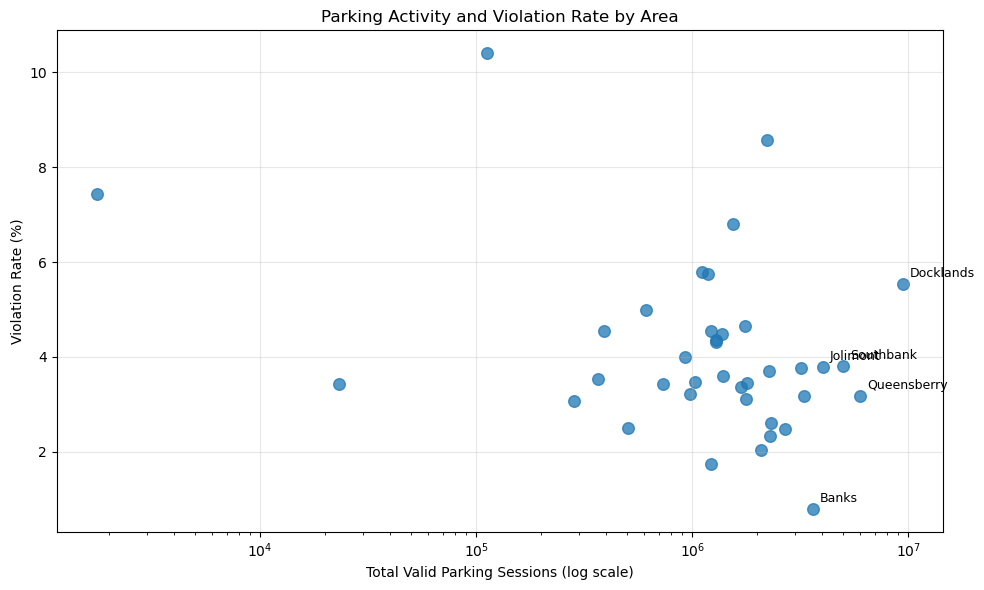

In [69]:
import numpy as np
import matplotlib.pyplot as plt

area_visualisation_pd = (
    area_visualisation_df.toPandas()
)

area_visualisation_pd["AreaLabel"] = (
    area_visualisation_pd["AreaName"]
    .fillna(
        "Area "
        + area_visualisation_pd["AreaId"].astype(str)
    )
)

x = area_visualisation_pd["TotalValidSessions"]
y = area_visualisation_pd["ViolationRate"]

area_activity_violation_correlation = (
    np.corrcoef(
        np.log10(x),
        y
    )[0, 1]
)

print(
    "Correlation between log10(TotalValidSessions) "
    f"and ViolationRate: "
    f"{area_activity_violation_correlation:.3f}"
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.scatter(
    x,
    y,
    s=70,
    alpha=0.75
)

# Label the five areas with the most sessions
for _, row in (
    area_visualisation_pd
    .nlargest(5, "TotalValidSessions")
    .iterrows()
):
    ax.annotate(
        row["AreaLabel"],
        (
            row["TotalValidSessions"],
            row["ViolationRate"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

ax.set_xscale("log")
ax.set_xlabel(
    "Total Valid Parking Sessions (log scale)"
)
ax.set_ylabel(
    "Violation Rate (%)"
)
ax.set_title(
    "Parking Activity and Violation Rate by Area"
)
ax.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

#### Plot 1 Discussion

The plot shows a weak-to-moderate negative relationship between parking activity and violation rate, with a correlation of -0.358 between log-transformed total sessions and violation rate. Areas with more parking sessions did not consistently have higher violation rates. For example, Banks had high parking activity but a very low violation rate, while other areas with fewer sessions recorded much higher rates. One limitation is that the area-level aggregation does not account for differences in parking restrictions, enforcement or time of day, and the relationship does not demonstrate causation.

### Plot 2: Hourly Parking Activity and Traffic Volume

**Question:** Are hours with higher average parking activity also associated with higher average traffic volume?

A scatter plot was selected because average parking activity and average traffic volume are both quantitative variables. Each point represents one hour of the day, while colour identifies the hour and helps show the time-of-day pattern.

In [70]:
# Aggregate matched blocks by hour
hourly_relationship_df = matched_area_time_blocks_df.withColumn(
    "HourOfDay",
    F.hour("BlockStart")
).groupBy(
    "HourOfDay"
).agg(
    F.round(
        F.avg("ParkingSessions"),
        2
    ).alias("AverageParkingSessions"),

    F.round(
        F.avg("TrafficVolume"),
        2
    ).alias("AverageTrafficVolume"),

    F.count("*").alias("MatchedBlocks")
).orderBy(
    "HourOfDay"
).cache()

In [71]:
# Display and count the aggregated dataset
hourly_relationship_count = hourly_relationship_df.count()

hourly_relationship_df.show(
    5,
    truncate=False
)

print(
    "Aggregated dataset row count:",
    hourly_relationship_count
)

+---------+----------------------+--------------------+-------------+
|HourOfDay|AverageParkingSessions|AverageTrafficVolume|MatchedBlocks|
+---------+----------------------+--------------------+-------------+
|0        |110.31                |1494.66             |26620        |
|1        |6.77                  |284.04              |22186        |
|2        |6.09                  |251.7               |20847        |
|3        |5.53                  |241.99              |20028        |
|4        |5.11                  |236.75              |20131        |
+---------+----------------------+--------------------+-------------+
only showing top 5 rows
Aggregated dataset row count: 24


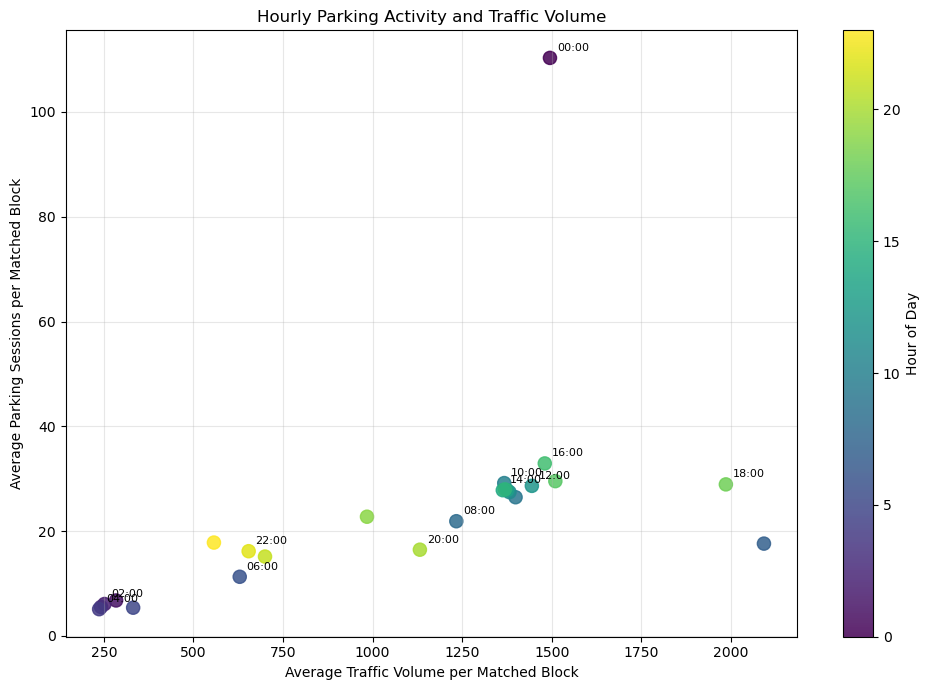

In [72]:
# Collect only the hourly aggregated dataset
hourly_relationship_pd = hourly_relationship_df.toPandas()

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    hourly_relationship_pd["AverageTrafficVolume"],
    hourly_relationship_pd["AverageParkingSessions"],
    c=hourly_relationship_pd["HourOfDay"],
    cmap="viridis",
    s=90,
    alpha=0.85
)

# Label every second hour
for _, row in hourly_relationship_pd.iterrows():
    if int(row["HourOfDay"]) % 2 == 0:
        plt.annotate(
            f'{int(row["HourOfDay"]):02d}:00',
            (
                row["AverageTrafficVolume"],
                row["AverageParkingSessions"]
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8
        )

plt.colorbar(
    scatter,
    label="Hour of Day"
)

plt.xlabel("Average Traffic Volume per Matched Block")
plt.ylabel("Average Parking Sessions per Matched Block")
plt.title("Hourly Parking Activity and Traffic Volume")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Plot 2 Discussion
The plot shows a generally positive relationship between average traffic volume and average parking activity, although the pattern is not consistent across every hour. Most low-traffic hours also had low parking activity, while many daytime hours recorded higher values for both measures. However, midnight was a clear outlier, with unusually high parking activity despite only moderate traffic volume. One limitation is that the hourly averages combine different areas and dates, so the pattern may hide spatial and daily variation; the midnight result may also reflect timestamp-recording behaviour.

In [73]:
# Release the cached plot datasets
area_visualisation_df.unpersist()
hourly_relationship_df.unpersist()

DataFrame[HourOfDay: int, AverageParkingSessions: double, AverageTrafficVolume: double, MatchedBlocks: bigint]

## Part 3 Query Optimisation (25%) <a class="anchor" name="part-3"></a>
Assume that the following monthly parking report will be generated regularly. A correct query is required first, but it should also execute efficiently on the full dataset. In this section, implement the report, inspect how Spark executes it, and evaluate the optimization.


Monthly parking report  
For each month, identify the five areas with the highest number of peak-hour parking sessions among areas whose peak-hour violation rate is greater than the monthly violation benchmark.  
Area Violation Rate = (Peak-hour sessions where inViolation is true) / (Peak-hour sessions with a valid inViolation value) * 100   
Monthly Violation Benchmark = (Peak-hour sessions where InViolation is true across all areas in the month) / (Peak-hour sessions with a valid InViolation value across all areas in the same month) * 100  
  
Display:  
- month;
- area id;
- area name;
- park session count;
- violation count;
- violation rate;
- monthly rank.  
Report the number of months and total result rows, Display the complete result ordered by Month and Monthly Rank in ascending order.

##### 3.1 DataFrame API and Spark SQL 
Implement the monthly report independently using:  
1. the PySpark DataFrame API;
2. Spark SQL  
Both implementations must begin with the same prepared input data. Do not create the SQL result by registering the completed DataFrame API result as a temporary view.  
  
Complete the following:  
1. Report the row count returned by each implementation
2. Confirm that the results are identical using exceptAll() in both directions, and display both mismatch counts.
3. For each implementation, display the first 20 result rows using the following column order: 
- Month
- AreaId
- AreaName
- PeakSessionCount
- ViolationCount
- ViolationRate
- MonthlyViolationBenchmark
- MonthlyRank
4. Order the displayed results by Month and MonthlyRank in ascending order.
5. Inspect the physical plan for each implementation, and briefly compare the operations. Briefly explain whether Spark selected different execution strategies, and why?


In [74]:
from pyspark.sql.window import Window
from pyspark import StorageLevel

# Prepare the common peak-hour input
monthly_peak_input_df = parking_area_df.filter(
    F.col("areaid").isNotNull()
    & F.col("arrivaltime").isNotNull()
    & F.col("isPeak")
).select(
    F.trunc(
        F.to_date("arrivaltime"),
        "month"
    ).alias("Month"),

    F.col("areaid").alias("AreaId"),
    F.col("AreaName"),
    F.col("inviolation").alias("InViolation")
)

# Register only the prepared input for Spark SQL
monthly_peak_input_df.createOrReplaceTempView(
    "monthly_peak_input"
)

In [75]:
# Calculate monthly metrics for each area
area_month_metrics_df = monthly_peak_input_df.groupBy(
    "Month",
    "AreaId",
    "AreaName"
).agg(
    F.count("*").alias("PeakSessionCount"),

    F.sum(
        F.when(
            F.col("InViolation") == True,
            1
        ).otherwise(0)
    ).alias("ViolationCount"),

    F.count("InViolation").alias(
        "ValidViolationSessions"
    )
).withColumn(
    "AreaViolationRateRaw",
    F.when(
        F.col("ValidViolationSessions") > 0,
        F.col("ViolationCount")
        / F.col("ValidViolationSessions")
        * 100
    )
)

In [76]:
# Calculate the monthly violation benchmark
monthly_benchmark_df = monthly_peak_input_df.groupBy(
    "Month"
).agg(
    F.sum(
        F.when(
            F.col("InViolation") == True,
            1
        ).otherwise(0)
    ).alias("MonthlyViolationCount"),

    F.count("InViolation").alias(
        "MonthlyValidViolationSessions"
    )
).withColumn(
    "MonthlyViolationBenchmarkRaw",
    F.when(
        F.col("MonthlyValidViolationSessions") > 0,
        F.col("MonthlyViolationCount")
        / F.col("MonthlyValidViolationSessions")
        * 100
    )
)

In [77]:
# Add the monthly benchmark and keep eligible areas
eligible_area_month_df = area_month_metrics_df.join(
    monthly_benchmark_df,
    on="Month",
    how="inner"
).filter(
    F.col("AreaViolationRateRaw").isNotNull()
    & F.col("MonthlyViolationBenchmarkRaw").isNotNull()
    & (
        F.col("AreaViolationRateRaw")
        > F.col("MonthlyViolationBenchmarkRaw")
    )
)

In [78]:
# Define the monthly ranking
monthly_ranking_window = Window.partitionBy(
    "Month"
).orderBy(
    F.desc("PeakSessionCount"),
    F.asc("AreaId")
)

# Create the DataFrame API report
dataframe_monthly_report_df = eligible_area_month_df.withColumn(
    "MonthlyRank",
    F.row_number().over(monthly_ranking_window)
).filter(
    F.col("MonthlyRank") <= 5
).select(
    "Month",
    "AreaId",
    "AreaName",
    "PeakSessionCount",
    "ViolationCount",

    F.round(
        F.col("AreaViolationRateRaw"),
        2
    ).alias("ViolationRate"),

    F.round(
        F.col("MonthlyViolationBenchmarkRaw"),
        2
    ).alias("MonthlyViolationBenchmark"),

    "MonthlyRank"
).orderBy(
    F.asc("Month"),
    F.asc("MonthlyRank")
)

In [79]:
# Create the report independently with Spark SQL
sql_monthly_report_df = spark.sql("""
WITH area_month_metrics AS (
    SELECT
        Month,
        AreaId,
        AreaName,
        COUNT(*) AS PeakSessionCount,
        SUM(
            CASE
                WHEN InViolation = TRUE THEN 1
                ELSE 0
            END
        ) AS ViolationCount,
        COUNT(InViolation) AS ValidViolationSessions
    FROM monthly_peak_input
    GROUP BY
        Month,
        AreaId,
        AreaName
),

monthly_benchmark AS (
    SELECT
        Month,
        SUM(
            CASE
                WHEN InViolation = TRUE THEN 1
                ELSE 0
            END
        ) AS MonthlyViolationCount,
        COUNT(InViolation) AS MonthlyValidViolationSessions
    FROM monthly_peak_input
    GROUP BY Month
),

area_with_benchmark AS (
    SELECT
        a.Month,
        a.AreaId,
        a.AreaName,
        a.PeakSessionCount,
        a.ViolationCount,
        CAST(a.ViolationCount AS DOUBLE)
            / CAST(a.ValidViolationSessions AS DOUBLE)
            * 100.0 AS AreaViolationRateRaw,
        CAST(m.MonthlyViolationCount AS DOUBLE)
            / CAST(m.MonthlyValidViolationSessions AS DOUBLE)
            * 100.0 AS MonthlyViolationBenchmarkRaw
    FROM area_month_metrics AS a
    INNER JOIN monthly_benchmark AS m
        ON a.Month = m.Month
    WHERE
        a.ValidViolationSessions > 0
        AND m.MonthlyValidViolationSessions > 0
),

eligible_areas AS (
    SELECT *
    FROM area_with_benchmark
    WHERE
        AreaViolationRateRaw
        > MonthlyViolationBenchmarkRaw
),

ranked_areas AS (
    SELECT
        Month,
        AreaId,
        AreaName,
        PeakSessionCount,
        ViolationCount,
        AreaViolationRateRaw,
        MonthlyViolationBenchmarkRaw,
        ROW_NUMBER() OVER (
            PARTITION BY Month
            ORDER BY
                PeakSessionCount DESC,
                AreaId ASC
        ) AS MonthlyRank
    FROM eligible_areas
)

SELECT
    Month,
    AreaId,
    AreaName,
    PeakSessionCount,
    ViolationCount,
    ROUND(
        AreaViolationRateRaw,
        2
    ) AS ViolationRate,
    ROUND(
        MonthlyViolationBenchmarkRaw,
        2
    ) AS MonthlyViolationBenchmark,
    MonthlyRank
FROM ranked_areas
WHERE MonthlyRank <= 5
ORDER BY
    Month ASC,
    MonthlyRank ASC
""")

In [80]:
# Inspect the DataFrame API physical plan
print("DataFrame API physical plan:")
dataframe_monthly_report_df.explain(
    mode="formatted"
)

# Inspect the Spark SQL physical plan
print("Spark SQL physical plan:")
sql_monthly_report_df.explain(
    mode="formatted"
)

DataFrame API physical plan:
== Physical Plan ==
AdaptiveSparkPlan (46)
+- Sort (45)
   +- Exchange (44)
      +- Project (43)
         +- Filter (42)
            +- Window (41)
               +- WindowGroupLimit (40)
                  +- Sort (39)
                     +- Project (38)
                        +- SortMergeJoin Inner (37)
                           :- Sort (18)
                           :  +- Exchange (17)
                           :     +- Project (16)
                           :        +- Filter (15)
                           :           +- HashAggregate (14)
                           :              +- Exchange (13)
                           :                 +- HashAggregate (12)
                           :                    +- Project (11)
                           :                       +- BroadcastHashJoin LeftOuter BuildRight (10)
                           :                          :- Project (3)
                           :                          :  

== Physical Plan ==
AdaptiveSparkPlan (44)
+- Sort (43)
   +- Exchange (42)
      +- Project (41)
         +- Filter (40)
            +- Window (39)
               +- WindowGroupLimit (38)
                  +- Sort (37)
                     +- Project (36)
                        +- SortMergeJoin Inner (35)
                           :- Sort (17)
                           :  +- Exchange (16)
                           :     +- Filter (15)
                           :        +- HashAggregate (14)
                           :           +- Exchange (13)
                           :              +- HashAggregate (12)
                           :                 +- Project (11)
                           :                    +- BroadcastHashJoin LeftOuter BuildRight (10)
                           :                       :- Project (3)
                           :                       :  +- Filter (2)
                           :                       :     +- Scan csv  (1)
              

In [81]:
# Cache both final results for repeated validation
dataframe_monthly_report_df = (
    dataframe_monthly_report_df
    .persist(StorageLevel.MEMORY_AND_DISK)
)

sql_monthly_report_df = (
    sql_monthly_report_df
    .persist(StorageLevel.MEMORY_AND_DISK)
)

# Materialise both results
dataframe_result_count = (
    dataframe_monthly_report_df.count()
)

sql_result_count = (
    sql_monthly_report_df.count()
)

report_month_count = (
    dataframe_monthly_report_df
    .select("Month")
    .distinct()
    .count()
)

print(
    "DataFrame API result row count:",
    dataframe_result_count
)

print(
    "Spark SQL result row count:",
    sql_result_count
)

print(
    "Number of months:",
    report_month_count
)

DataFrame API result row count: 120
Spark SQL result row count: 120
Number of months: 24


In [82]:
# Display the first 20 DataFrame API rows
print("DataFrame API first 20 rows:")

dataframe_monthly_report_df.show(
    20,
    truncate=False
)

# Display the first 20 Spark SQL rows
print("Spark SQL first 20 rows:")

sql_monthly_report_df.show(
    20,
    truncate=False
)

DataFrame API first 20 rows:
+----------+------+---------------+----------------+--------------+-------------+-------------------------+-----------+
|Month     |AreaId|AreaName       |PeakSessionCount|ViolationCount|ViolationRate|MonthlyViolationBenchmark|MonthlyRank|
+----------+------+---------------+----------------+--------------+-------------+-------------------------+-----------+
|2018-01-01|35    |Docklands      |85792           |5606          |6.53         |5.34                     |1          |
|2018-01-01|38    |Southbank      |45155           |2470          |5.47         |5.34                     |2          |
|2018-01-01|6     |Titles         |19818           |1115          |5.63         |5.34                     |3          |
|2018-01-01|13    |Princes Theatre|17223           |1252          |7.27         |5.34                     |4          |
|2018-01-01|20    |Courtney       |12275           |1605          |13.08        |5.34                     |5          |
|2018-02-01

In [83]:
# Check DataFrame API rows missing from Spark SQL
dataframe_minus_sql_count = (
    dataframe_monthly_report_df
    .exceptAll(sql_monthly_report_df)
    .count()
)

# Check Spark SQL rows missing from DataFrame API
sql_minus_dataframe_count = (
    sql_monthly_report_df
    .exceptAll(dataframe_monthly_report_df)
    .count()
)

print(
    "DataFrame API EXCEPT ALL Spark SQL:",
    dataframe_minus_sql_count
)

print(
    "Spark SQL EXCEPT ALL DataFrame API:",
    sql_minus_dataframe_count
)

DataFrame API EXCEPT ALL Spark SQL: 0
Spark SQL EXCEPT ALL DataFrame API: 0


In [84]:
# Display the complete monthly report
print("Complete monthly parking report:")

dataframe_monthly_report_df.show(
    dataframe_result_count,
    truncate=False
)

Complete monthly parking report:
+----------+------+---------------+----------------+--------------+-------------+-------------------------+-----------+
|Month     |AreaId|AreaName       |PeakSessionCount|ViolationCount|ViolationRate|MonthlyViolationBenchmark|MonthlyRank|
+----------+------+---------------+----------------+--------------+-------------+-------------------------+-----------+
|2018-01-01|35    |Docklands      |85792           |5606          |6.53         |5.34                     |1          |
|2018-01-01|38    |Southbank      |45155           |2470          |5.47         |5.34                     |2          |
|2018-01-01|6     |Titles         |19818           |1115          |5.63         |5.34                     |3          |
|2018-01-01|13    |Princes Theatre|17223           |1252          |7.27         |5.34                     |4          |
|2018-01-01|20    |Courtney       |12275           |1605          |13.08        |5.34                     |5          |
|2018-0

In [85]:
# Compare the output schemas
print("DataFrame API schema:")
dataframe_monthly_report_df.printSchema()

print("Spark SQL schema:")
sql_monthly_report_df.printSchema()

print(
    "Same column order:",
    dataframe_monthly_report_df.columns
    == sql_monthly_report_df.columns
)

print(
    "Same data types:",
    dataframe_monthly_report_df.dtypes
    == sql_monthly_report_df.dtypes
)

DataFrame API schema:
root
 |-- Month: date (nullable = true)
 |-- AreaId: integer (nullable = true)
 |-- AreaName: string (nullable = true)
 |-- PeakSessionCount: long (nullable = false)
 |-- ViolationCount: long (nullable = true)
 |-- ViolationRate: double (nullable = true)
 |-- MonthlyViolationBenchmark: double (nullable = true)
 |-- MonthlyRank: integer (nullable = false)

Spark SQL schema:
root
 |-- Month: date (nullable = true)
 |-- AreaId: integer (nullable = true)
 |-- AreaName: string (nullable = true)
 |-- PeakSessionCount: long (nullable = false)
 |-- ViolationCount: long (nullable = true)
 |-- ViolationRate: double (nullable = true)
 |-- MonthlyViolationBenchmark: double (nullable = true)
 |-- MonthlyRank: integer (nullable = false)

Same column order: True
Same data types: True


### 3.1 DataFrame API and Spark SQL Comparison

Both implementations produced very similar physical plans. Each plan scanned the parking data twice because the area-month metrics and the monthly violation benchmark were calculated through separate branches. Both branches used a broadcast hash join for the small area lookup, followed by partial and final HashAggregate operations with Exchange.

The two aggregated branches were combined using an inner SortMergeJoin on `Month`. WindowGroupLimit and Window operations were then used to rank the areas and select the top five for each month. A final Exchange and Sort ordered the results by `Month` and `MonthlyRank`.

The DataFrame API plan contained 46 nodes, while the Spark SQL plan contained 44 nodes. The small difference was mainly caused by additional Project operations in the DataFrame API plan. Spark selected the same main execution strategies because both implementations expressed the same calculation and Catalyst optimised them in a similar way.

##### 3.2 Baseline plan and Spark UI analysis  
Select either SQL or DataFrame API from Section 3.1 as a baseline. Clearly state which implementation you selected.  
Before running the baseline query, set: sc.setJobDescription(f"A1-P3-2-Baseline-{student_auth_code}")  
Execute an action that materialises the complete final result and record the wall-clock execution time. Use the same action later when evaluating the optimised query.  
Submit and include:  
- the formatted physical plan, you may refer to the plan already printed in Section 3.1 rather than printing it again.
- Spark UI screenshots clearly showing: the job description, the SQL/DAG, the relevant stage details, relevant shuffle-read, shuffle-write figures, where applicable.
- the measured execution time;  
In no more than 300 words:  
1. Identify the most expensive stages or operations.
2. Support the explanation using numbers visible in your screenshots.
3. Suggest an improvement strategy.


### 3.2 Baseline Selection

The DataFrame API implementation was selected as the baseline. It produced the verified monthly report and provides a clear sequence of aggregations, join operations and window-based ranking for performance analysis. The formatted physical plan printed in Section 3.1 is used as the baseline plan.

In [86]:
# Remove cached final results
dataframe_monthly_report_df.unpersist(
    blocking=True
)

sql_monthly_report_df.unpersist(
    blocking=True
)

# Clear any remaining Spark cache
spark.catalog.clearCache()

In [87]:
import time


def timed_collect(dataframe, job_description):
    """Run a fresh query plan and return its rows and execution time."""

    # Remove cached results
    dataframe.unpersist(blocking=True)
    spark.catalog.clearCache()

    # Create a fresh query execution
    fresh_dataframe = dataframe.select(
        *dataframe.columns
    )

    # Set the required job description
    sc.setJobDescription(job_description)

    try:
        start_time = time.perf_counter()

        # Materialise the complete result
        result_rows = fresh_dataframe.collect()

        execution_seconds = (
            time.perf_counter() - start_time
        )
    finally:
        sc.setJobDescription(None)

    return result_rows, execution_seconds

In [88]:
# Run the DataFrame API baseline
baseline_result_rows, baseline_execution_seconds = timed_collect(
    dataframe_monthly_report_df,
    f"A1-P3-2-Baseline-{student_auth_code}"
)

print(
    "Baseline result row count:",
    len(baseline_result_rows)
)

print(
    "Baseline execution time:",
    f"{baseline_execution_seconds:.2f} seconds"
)

Baseline result row count: 120
Baseline execution time: 416.77 seconds


### 3.2 Baseline Spark UI Evidence

<img src="screenshots/part3/p3_baseline_jobs.png" width="100%">

**Figure 8:** Spark Jobs tab showing the baseline jobs with the required job description `A1-P3-2-Baseline-kzha0139`. Jobs 132–139 correspond to the Section 3.2 baseline run, while Jobs 140–148 show the repeated baseline run used later for the Section 3.3 comparison.


<img src="screenshots/part3/p3_baseline_sql_dag.png" width="100%">

**Figure 9:** SQL/DataFrame DAG for the DataFrame API baseline. The DAG shows two independent parking-data branches used to calculate the area-month metrics and the monthly violation benchmark before joining and ranking the results.

<img src="screenshots/part3/p3_baseline_stages.png" width="100%">

**Figure 10:** The two main baseline stages. Stages 317 and 318 each processed 72,912,582 records (8.6 GiB) using 69 tasks.

<img src="screenshots/part3/p3_baseline_stage_a_details.png" width="100%">

**Figure 11:** Stage 317 calculated the area-month metrics. It processed 8.6 GiB in 3.6 minutes and wrote 965.2 KiB containing 14,294 shuffle records.

<img src="screenshots/part3/p3_baseline_stage_b_details.png" width="100%">

**Figure 12:** Stage 318 calculated the monthly violation benchmark. It processed the same 8.6 GiB input and wrote 58.3 KiB containing 868 shuffle records.


### 3.2 Baseline Plan and Performance Analysis

The DataFrame API baseline returned 120 rows and required 416.77 seconds. The physical plan and SQL DAG show two independent branches: one calculates the area-month metrics, while the other calculates the monthly violation benchmark.

Stages 317 and 318 were the main expensive stages. Both used 69 tasks and separately processed all 72,912,582 parking records, or 8.6 GiB. Stage 317 took 3.6 minutes and wrote 965.2 KiB of shuffle data. Stage 318 had an elapsed duration of 6.9 minutes and wrote 58.3 KiB. Its elapsed time included waiting for available execution resources while the other branch was running.

The shuffle outputs were relatively small, so the main cost came from scanning and processing the full parking dataset twice rather than from shuffle volume. A suitable improvement is to calculate the area-month metrics once and derive the monthly benchmark from this aggregated result using a window operation. This removes the second full scan and the SortMergeJoin between the two branches.

##### 3.3 Evaluate one optimisation  
Implement one optimisation based on the evidence and reasoning presented in Section 3.2. Briefly state what you changed and why you expect it to improve execution.  
Before executing it, set: sc.setJobDescription(f"A1-P3-3-Optimised-{student_auth_code}")  
Then:  
1. Run the baseline and revised queries under the same conditions;
2. Confirm that the optimised query produces exactly the same result as the baseline
3. Record the execution time and collect the corresponding Spark UI evidence.
4. Decide whether the optimisation should be retained, justify your decision.
5. A technically reasonable improvement and evidence-based evaluation are required for full marks.


### 3.3 Optimisation Strategy

The baseline calculated the area-month metrics and monthly benchmark through two independent branches, causing the large parking dataset to be scanned and processed twice. The optimised query calculates the area-month metrics once, then derives each monthly benchmark by summing the aggregated violation counts and valid-violation counts with a month-partitioned window. This is expected to remove the second full parking scan and the SortMergeJoin between the two aggregation branches.

In [89]:
# Calculate the area-month metrics once
optimized_area_month_metrics_df = monthly_peak_input_df.groupBy(
    "Month",
    "AreaId",
    "AreaName"
).agg(
    F.count("*").alias("PeakSessionCount"),

    F.sum(
        F.when(
            F.col("InViolation") == True,
            1
        ).otherwise(0)
    ).alias("ViolationCount"),

    F.count("InViolation").alias(
        "ValidViolationSessions"
    )
)

In [90]:
# Define the monthly totals window
monthly_totals_window = Window.partitionBy(
    "Month"
)

# Derive the monthly benchmark from area-level totals
optimized_metrics_df = optimized_area_month_metrics_df.withColumn(
    "MonthlyViolationCount",
    F.sum("ViolationCount").over(
        monthly_totals_window
    )
).withColumn(
    "MonthlyValidViolationSessions",
    F.sum("ValidViolationSessions").over(
        monthly_totals_window
    )
).withColumn(
    "AreaViolationRateRaw",
    F.when(
        F.col("ValidViolationSessions") > 0,
        F.col("ViolationCount")
        / F.col("ValidViolationSessions")
        * 100
    )
).withColumn(
    "MonthlyViolationBenchmarkRaw",
    F.when(
        F.col("MonthlyValidViolationSessions") > 0,
        F.col("MonthlyViolationCount")
        / F.col("MonthlyValidViolationSessions")
        * 100
    )
).filter(
    F.col("AreaViolationRateRaw").isNotNull()
    & F.col("MonthlyViolationBenchmarkRaw").isNotNull()
    & (
        F.col("AreaViolationRateRaw")
        > F.col("MonthlyViolationBenchmarkRaw")
    )
)

In [91]:
# Define the optimised ranking window
optimized_ranking_window = Window.partitionBy(
    "Month"
).orderBy(
    F.desc("PeakSessionCount"),
    F.asc("AreaId")
)

# Create the optimised monthly report
optimized_monthly_report_df = optimized_metrics_df.withColumn(
    "MonthlyRank",
    F.row_number().over(
        optimized_ranking_window
    )
).filter(
    F.col("MonthlyRank") <= 5
).select(
    "Month",
    "AreaId",
    "AreaName",
    "PeakSessionCount",
    "ViolationCount",

    F.round(
        F.col("AreaViolationRateRaw"),
        2
    ).alias("ViolationRate"),

    F.round(
        F.col("MonthlyViolationBenchmarkRaw"),
        2
    ).alias("MonthlyViolationBenchmark"),

    "MonthlyRank"
).orderBy(
    F.asc("Month"),
    F.asc("MonthlyRank")
)

In [92]:
# Inspect the optimised physical plan
optimized_monthly_report_df.explain(
    mode="formatted"
)

== Physical Plan ==
AdaptiveSparkPlan (27)
+- Sort (26)
   +- Exchange (25)
      +- Project (24)
         +- Filter (23)
            +- Window (22)
               +- WindowGroupLimit (21)
                  +- Sort (20)
                     +- Project (19)
                        +- Filter (18)
                           +- Window (17)
                              +- Sort (16)
                                 +- Exchange (15)
                                    +- HashAggregate (14)
                                       +- Exchange (13)
                                          +- HashAggregate (12)
                                             +- Project (11)
                                                +- BroadcastHashJoin LeftOuter BuildRight (10)
                                                   :- Project (3)
                                                   :  +- Filter (2)
                                                   :     +- Scan csv  (1)
                           

In [93]:
# Run the baseline under the comparison conditions
baseline_comparison_rows, baseline_comparison_seconds = timed_collect(
    dataframe_monthly_report_df,
    f"A1-P3-2-Baseline-{student_auth_code}"
)

# Run the optimised query under the same conditions
optimized_result_rows, optimized_execution_seconds = timed_collect(
    optimized_monthly_report_df,
    f"A1-P3-3-Optimised-{student_auth_code}"
)

print(
    "Baseline row count:",
    len(baseline_comparison_rows)
)

print(
    "Baseline execution time:",
    f"{baseline_comparison_seconds:.2f} seconds"
)

print(
    "Optimised row count:",
    len(optimized_result_rows)
)

print(
    "Optimised execution time:",
    f"{optimized_execution_seconds:.2f} seconds"
)

Baseline row count: 120
Baseline execution time: 403.00 seconds
Optimised row count: 120
Optimised execution time: 195.50 seconds


In [94]:
# Compare the output structure
same_columns = (
    dataframe_monthly_report_df.columns
    == optimized_monthly_report_df.columns
)

same_data_types = (
    dataframe_monthly_report_df.dtypes
    == optimized_monthly_report_df.dtypes
)

# Compare every ordered result row
same_rows = (
    baseline_comparison_rows
    == optimized_result_rows
)

print(
    "Same column order:",
    same_columns
)

print(
    "Same data types:",
    same_data_types
)

print(
    "Rows exactly identical:",
    same_rows
)

Same column order: True
Same data types: True
Rows exactly identical: True


In [95]:
# Calculate the performance change
time_saved_seconds = (
    baseline_comparison_seconds
    - optimized_execution_seconds
)

runtime_reduction_percentage = (
    time_saved_seconds
    / baseline_comparison_seconds
    * 100
)

speedup = (
    baseline_comparison_seconds
    / optimized_execution_seconds
)

print(
    "Time saved:",
    f"{time_saved_seconds:.2f} seconds"
)

print(
    "Runtime reduction:",
    f"{runtime_reduction_percentage:.2f}%"
)

print(
    "Speed-up:",
    f"{speedup:.2f} times"
)

Time saved: 207.50 seconds
Runtime reduction: 51.49%
Speed-up: 2.06 times


### 3.3 Optimised Spark UI Evidence

<img src="screenshots/part3/p3_optimized_jobs.png" width="100%">

**Figure 13:** Spark Jobs tab showing Jobs 149–154 executed with the required job description `A1-P3-3-Optimised-kzha0139`. The complete optimised query required 195.50 seconds.

<img src="screenshots/part3/p3_optimized_sql_dag.png" width="100%">

**Figure 14:** SQL/DataFrame DAG for the optimised monthly report. The plan contains one parking-data scan and calculates the monthly benchmark from the aggregated area-month result using a window operation.

<img src="screenshots/part3/p3_optimized_stages.png" width="100%">

**Figure 15:** Optimised stages and shuffle metrics. Stage 347 processed the full 8.6 GiB input and wrote 965.2 KiB of shuffle data. The later stages processed much smaller intermediate results.

<img src="screenshots/part3/p3_optimized_stage_details.png" width="100%">

**Figure 16:** Stage 347 was the main optimised stage. It processed 72,912,582 records using 69 tasks in 3.2 minutes and wrote 965.2 KiB containing 14,294 shuffle records.


### 3.3 Optimisation Evaluation

The baseline required 403.00 seconds, while the optimised query required 195.50 seconds. This saved 207.50 seconds, representing a 51.49% runtime reduction and a 2.06 times speed-up. Both queries returned 120 rows, and their schemas and complete ordered results were identical.

The baseline used two separate branches that each scanned and processed the full 8.6 GiB parking dataset. The optimised plan calculated the area-month metrics once and used a month-partitioned window to derive the monthly benchmark. This removed the second full parking-data scan and the SortMergeJoin between the two baseline branches.

The Spark UI confirms that the optimised query used only one main full-data stage. Stage 347 read 72,912,582 records and wrote 965.2 KiB of shuffle data. Stage 349 then read this data and reduced it to 31.0 KiB, while the remaining stages processed only small aggregated results.

The optimisation should be retained because it produces exactly the same result while removing repeated processing and reducing the execution time by more than half.